### ***This is where i break down and work the problem of the integration and pipeline***

Idea of pipeline:

1. ***Potential field engine -  computes the time-varying subharmonic fields Φ(x,t) and their derivatives***

At each timestep (OR MAYBE TO SAVE COMPUTATION WE COULD TRY FINDING AN UPDATE WINDOW OF 2-3 TIMESTEPS?), I have obstacle positions

Project them onto a horizontal grid at the drone's current altitude

Then solve for a field where Laplace's equation is satisfied with the boundary conditions , and then add a positive Laplacian perturbation ( smth like a Gaussian bump: ΔΦ_perturbation = A * exp(-||x - x_goal||² / σ²) where A > 0) near the goal region to make it subharmonic (this amplifies the gradients where needed)

NOTE: the idea is to solve for harmonic since it's equation, then add perturbation to the field to get the subharmonic 

**-> To solve the Laplacian equation:** Gauss-Seidel or Successive Over-Relaxation (SOR) for discrete eq.

**-> To find derivatives:**

For ∂Φ/∂t, I need to compare the current field with the previous timestep

->After computing Φ(x, t) and having stored Φ(x, t-Δt) from the last control cycle, the temporal derivative at any point is approximately (Φ(x,t) - Φ(x,t-Δt)) / Δt - this signal tells how fast the field is changing at each location due to obstacle motion - so a large positive ∂Φ/∂t means the potential is increasing there, which likely indicates an obstacle is approaching that region.

**=> Observation space:** - the drone's position and velocity (standard navigation info), distances to nearby obstacles (standard collision avoidance), goal direction vector (standard goal-reaching), potential field additions: the current potential value Φ(x_current, t), the spatial gradient ∇Φ as a 3D (or 2D for horizontal plane) vector, the temporal derivative ∂Φ/∂t (infor about obstacle motion)

2. ***Reward function***

[NEED TO INFORM MYSELF AND MODEL]

3. ***Integration with PPO***

========================================

#### 1. Potential field engine - from potential_field_engine.py

PLAN: 
Demonstration of Potential Field Engine

This shows three aspects of the potential field engine:

1. HARMONIC FIELDS (Static): Basic implementation showing how harmonic potential fields eliminate local minima but suffer from flat regions

2. SUBHARMONIC FIELDS (Static): Shows how the perturbation amplifies gradients near the goal, addressing the flat region problem

3. TIME-VARYING FIELDS (Dynamic): Shows how the field adapts to moving obstacles and how ∂Φ/∂t provides predictive information

In [1]:
import importlib
import numpy as np
import matplotlib.pyplot as plt
import potential_field_engine
importlib.reload(potential_field_engine)
from potential_field_engine import PotentialFieldEngine2D

Demo 1: STATIC HARMONIC FIELD
Now solving harmonic field (∇²Φ = 0) (struggle time)
Harmonic field reached max iterations (1000) without full convergence

At position [ 0.  -1.5]:
  Potential Φ = 0.9221
  Gradient ∇Φ = [0.0450, 0.0401]
  Gradient magnitude = 0.0603


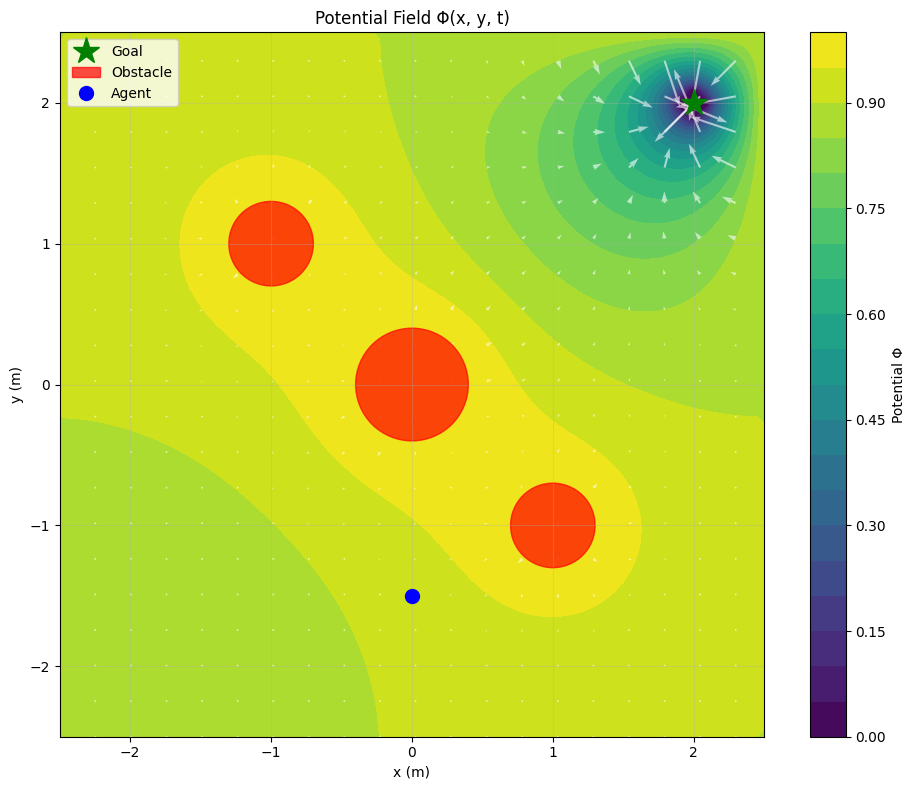

In [2]:
def demo_1_static_harmonic_field():
    """
    Static Harmonic Field:
    - This shows the basic harmonic potential field with static obstacles
    The field has no local minima, but far from the goal, the gradients become very weak (the "flat region problem").
    """
    print("Demo 1: STATIC HARMONIC FIELD")
    
    #create the potential field engine
    #working in a 5m x 5m workspace for simplicity
    pf_engine = PotentialFieldEngine2D(
        x_bounds=(-2.5, 2.5),
        y_bounds=(-2.5, 2.5),
        grid_resolution=100,
        goal_position=np.array([2.0, 2.0]),
        max_iterations=1000,
        convergence_threshold=1e-4
    )
    
    #add some static obstacles
    #these represent walls or static objects in the environment
    pf_engine.add_obstacle(position=np.array([0.0, 0.0]), radius=0.4)
    pf_engine.add_obstacle(position=np.array([1.0, -1.0]), radius=0.3)
    pf_engine.add_obstacle(position=np.array([-1.0, 1.0]), radius=0.3)
    
    print("Now solving harmonic field (∇²Φ = 0) (struggle time)")
    
    #solve for the harmonic field
    iterations = pf_engine.solve_harmonic_field(verbose=True)
    
    #test gradient at a sample position
    test_position = np.array([0.0, -1.5])
    gradient = pf_engine.compute_gradient(test_position)
    potential = pf_engine.compute_potential(test_position)
    
    print(f"\nAt position {test_position}:")
    print(f"  Potential Φ = {potential:.4f}")
    print(f"  Gradient ∇Φ = [{gradient[0]:.4f}, {gradient[1]:.4f}]")
    print(f"  Gradient magnitude = {np.linalg.norm(gradient):.4f}")
    

    fig = pf_engine.visualize(
        show_gradient=True,
        gradient_skip=5,
        agent_position=test_position,
        save_path='visualizations/demo1_harmonic_field.png'
    )
    plt.show()

demo_1_static_harmonic_field()

Demo 2: STATIC SUBHARMONIC FIELD
Harmonic field reached max iterations (1000) without full convergence

 HARMONIC FIELD (before perturbation)
Position [1.5 1.5] (dist to goal: 0.71m): |grad| = 0.3390
Position [1. 1.] (dist to goal: 1.41m): |grad| = 0.1502
Position [ 0.  -1.5] (dist to goal: 4.03m): |grad| = 0.0603

 SUBHARMONIC FIELD (after applying analytical field)
Position [1.5 1.5] (dist to goal: 0.71m):
  Harmonic:    |grad| = 0.3390
  Subharmonic: |grad| = 0.0740
  Improvement: -78.2%
Position [1. 1.] (dist to goal: 1.41m):
  Harmonic:    |grad| = 0.1502
  Subharmonic: |grad| = 0.5147
  Improvement: +242.7%
Position [ 0.  -1.5] (dist to goal: 4.03m):
  Harmonic:    |grad| = 0.0603
  Subharmonic: |grad| = 0.7551
  Improvement: +1152.6%


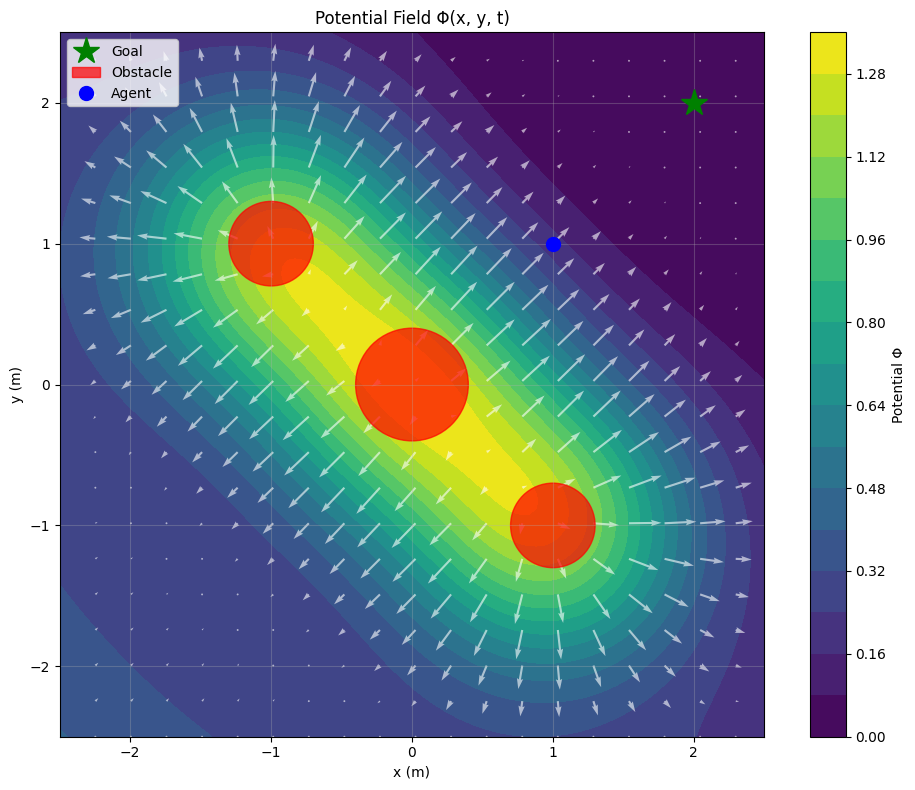

In [3]:
def demo_2_static_subharmonic_field():
    """
    Static Subharmonic Field:
    - This shows how the analytical subharmonic field (arXiv:2402.11601) amplifies gradients
    - Testing at multiple positions to show both near-goal and far-from-goal effects
    """
    print("Demo 2: STATIC SUBHARMONIC FIELD")
    
    #same setup as Demo 1
    pf_engine = PotentialFieldEngine2D(
        x_bounds=(-2.5, 2.5),
        y_bounds=(-2.5, 2.5),
        grid_resolution=100,
        goal_position=np.array([2.0, 2.0]),
        max_iterations=1000,
        convergence_threshold=1e-4
    )
    
    #same obstacles as Demo 1 for comparison
    pf_engine.add_obstacle(position=np.array([0.0, 0.0]), radius=0.4)
    pf_engine.add_obstacle(position=np.array([1.0, -1.0]), radius=0.3)
    pf_engine.add_obstacle(position=np.array([-1.0, 1.0]), radius=0.3)
    
    #first solve harmonic field
    pf_engine.solve_harmonic_field(verbose=True)
    
    #test at multiple positions to understand the effect
    test_positions = [
        np.array([1.5, 1.5]),   # close to goal
        np.array([1.0, 1.0]),   # medium distance
        np.array([0.0, -1.5])   # far from goal
    ]
    
    print("\n HARMONIC FIELD (before perturbation)")
    harmonic_gradients = []
    for pos in test_positions:
        grad = pf_engine.compute_gradient(pos)
        grad_mag = np.linalg.norm(grad)
        harmonic_gradients.append(grad_mag)
        dist_to_goal = np.linalg.norm(pos - pf_engine.goal_position)
        print(f"Position {pos} (dist to goal: {dist_to_goal:.2f}m): |grad| = {grad_mag:.4f}")
    
    #apply analytical subharmonic field (arXiv:2402.11601 Eq. 23)
    pf_engine.solve_subharmonic_field(a_att=0.01, a_rep=1.0, k_rep=1.0)
    
    print("\n SUBHARMONIC FIELD (after applying analytical field)")
    for i, pos in enumerate(test_positions):
        grad = pf_engine.compute_gradient(pos)
        grad_mag = np.linalg.norm(grad)
        dist_to_goal = np.linalg.norm(pos - pf_engine.goal_position)
        improvement = (grad_mag / harmonic_gradients[i] - 1) * 100
        
        print(f"Position {pos} (dist to goal: {dist_to_goal:.2f}m):")
        print(f"  Harmonic:    |grad| = {harmonic_gradients[i]:.4f}")
        print(f"  Subharmonic: |grad| = {grad_mag:.4f}")
        print(f"  Improvement: {improvement:+.1f}%")
    
    #visualize using the middle position
    fig = pf_engine.visualize(
        show_gradient=True,
        gradient_skip=5,
        agent_position=test_positions[1],
        save_path='visualizations/demo2_subharmonic_field.png'
    )
    plt.show()
    
demo_2_static_subharmonic_field()

Demo 3: DYNAMIC MULTI-OBSTACLE AVOIDANCE (Analytical Subharmonic)
  Obs A: pos=[-0.5  0. ], vel=[0.35 0.  ], r=0.40  (fast horizontal)
  Obs B: pos=[ 1.5 -1. ], vel=[-0.15  0.25], r=0.35  (diagonal sweeper)
  Obs C: pos=[0.8 1.8], vel=[0,0],        r=0.30  (static guard)

  Agent start : [-2. -2.]
  Goal        : [2. 2.]
  a_att=0.02, a_rep=1.0, k_rep=1.5
  Danger distance d0 = 0.82 m
  t=  0.0s  agent=[-1.93,-1.93]  d_goal=5.56  |grad|=0.2256  ∂Φ/∂t=-0.0001
  t=  5.0s  agent=[+0.34,+1.12]  d_goal=1.88  |grad|=0.8838  ∂Φ/∂t=+0.1483

  >> Goal reached at step 94  (d=0.310 m, t=9.4 s)

  Recomputing grid for visualization...


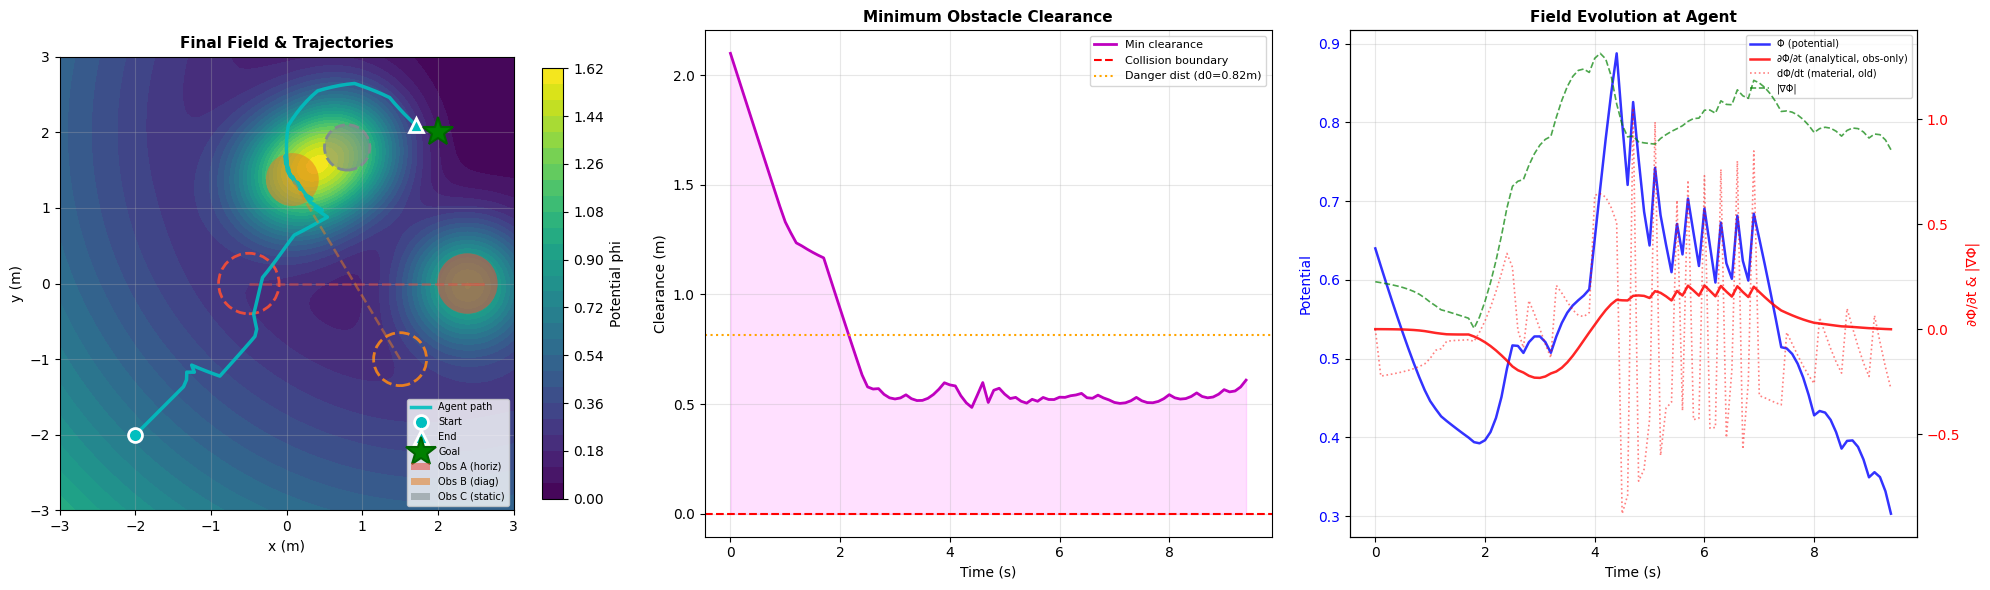

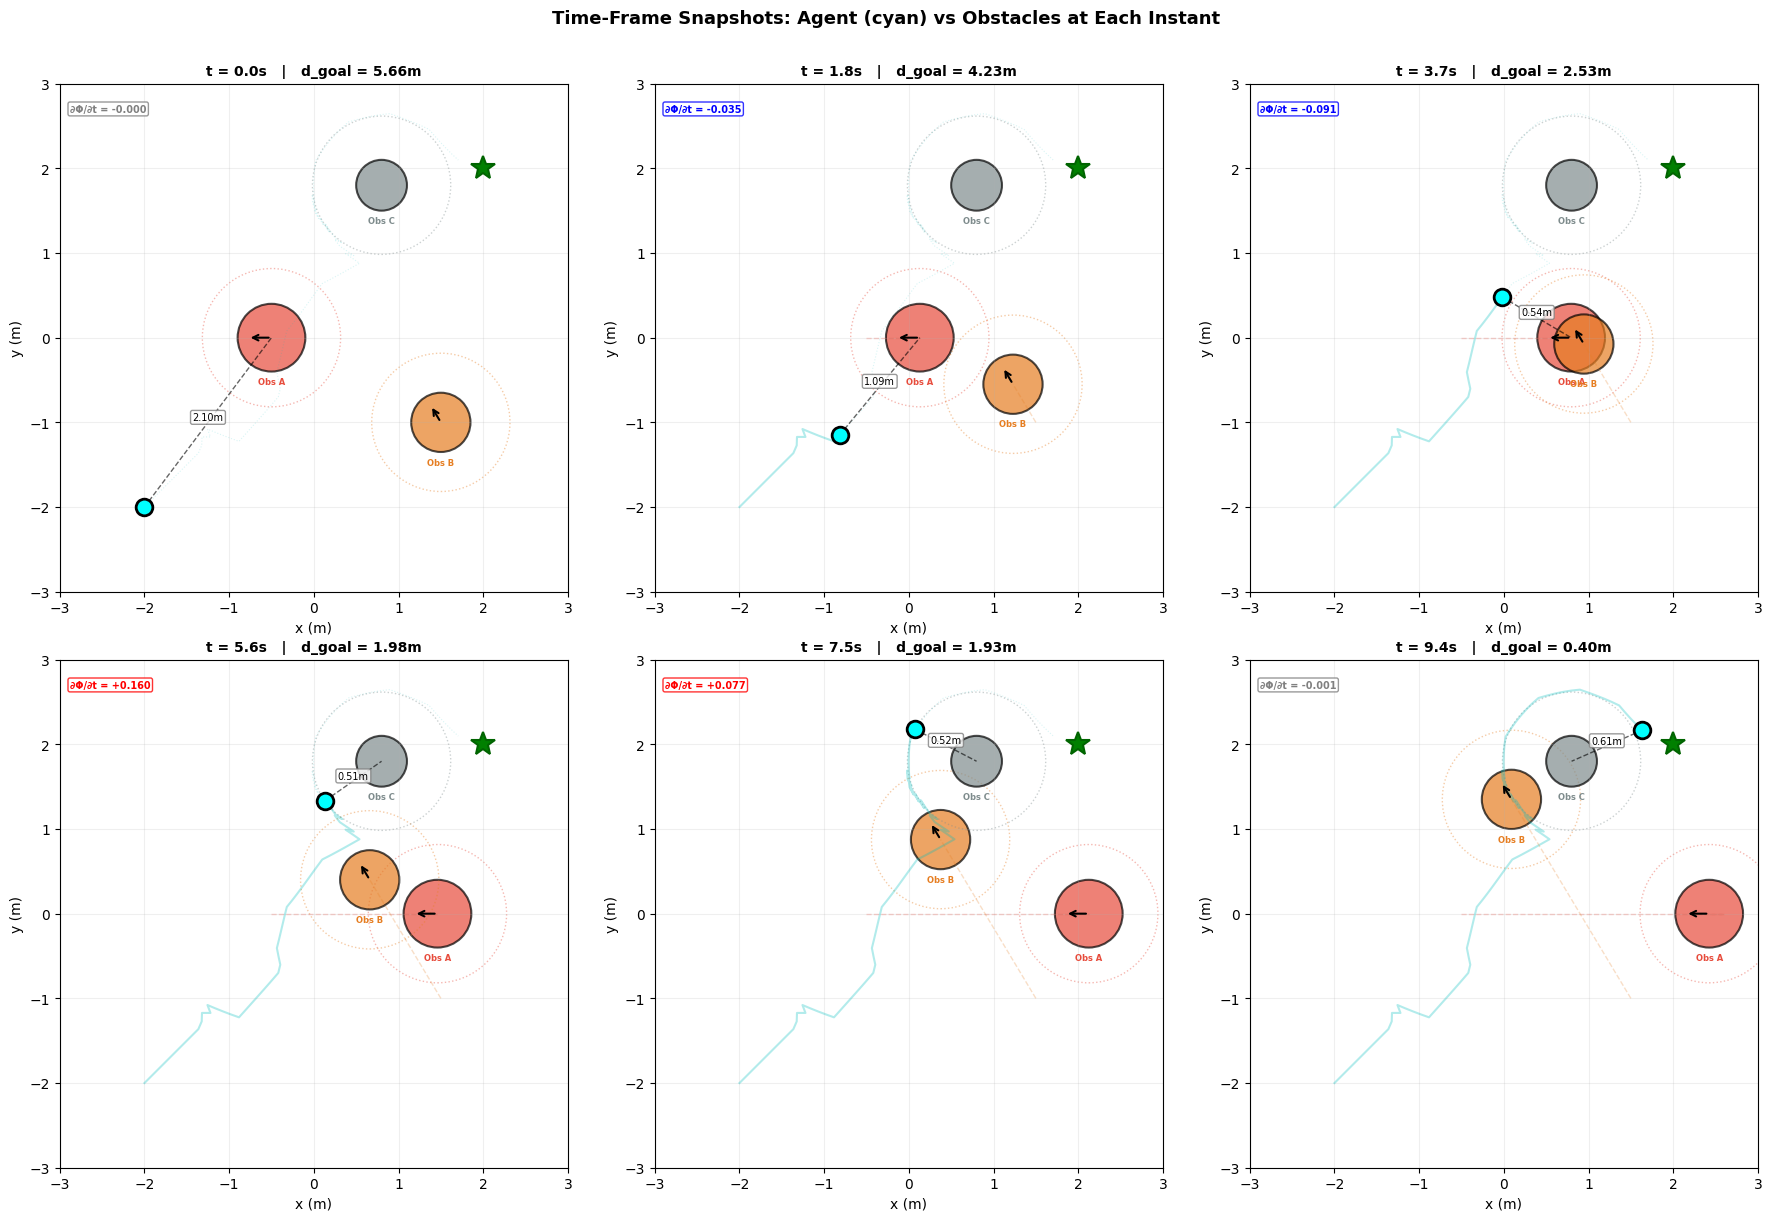


DYNAMIC OBSTACLE AVOIDANCE - SUMMARY
  Steps          : 95
  Sim time       : 9.5 s
  Path length    : 9.50 m  (straight-line: 5.66 m, ratio: 1.68)
  Goal reached   : YES
  Collision      : NO
  Min clearance  : 0.485 m
  ∂Φ/∂t range   : [-0.2323, 0.2080]  (analytical)
  dΦ/dt range   : [-0.8790, 1.0524]  (material, old)
  |∇Φ| range    : [0.0040, 1.3132]
  Obs A (horiz)       : moved 3.31 m,  final pos [+2.39, +0.00]
  Obs B (diag)        : moved 2.77 m,  final pos [+0.08, +1.37]
  Obs C (static)      : moved 0.00 m,  final pos [+0.80, +1.80]


In [4]:
def demo_3_dynamic_obstacles():
    """
    Dynamic Multi-Obstacle Avoidance using Analytical Subharmonic Fields
    ====================================================================
    Multiple obstacles move with different velocities, crossing the agent's
    planned path. The analytical subharmonic field (arXiv:2402.11601) adapts
     via update_field_analytical().

    Navigation uses gradient descent + circular sampling (Section IV).

    Temporal derivative ∂Φ/∂t is computed analytically (closed-form via
    chain rule through Gaussian barriers), giving a pure obstacle-motion
    signal decoupled from agent movement.

    Scenario (6x6 workspace):
      - Agent: (-2, -2) -> goal (2, 2)
      - Obs A: horizontal sweeper crossing diagonal (fast)
      - Obs B: diagonal sweeper creating dynamic pinch points
      - Obs C: static guard near the goal corridor
    """
    print("Demo 3: DYNAMIC MULTI-OBSTACLE AVOIDANCE (Analytical Subharmonic)")
    print("=" * 65)

    pf = PotentialFieldEngine2D(
        x_bounds=(-3.0, 3.0),
        y_bounds=(-3.0, 3.0),
        grid_resolution=80,
        goal_position=np.array([2.0, 2.0]),
        max_iterations=500,
        convergence_threshold=1e-4,
    )

    obs_A_pos = np.array([-0.5, 0.0])
    obs_A_vel = np.array([0.35, 0.0])
    pf.add_obstacle(position=obs_A_pos.copy(), radius=0.40, velocity=obs_A_vel)

    obs_B_pos = np.array([1.5, -1.0])
    obs_B_vel = np.array([-0.15, 0.25])
    pf.add_obstacle(position=obs_B_pos.copy(), radius=0.35, velocity=obs_B_vel)

    obs_C_pos = np.array([0.8, 1.8])
    pf.add_obstacle(position=obs_C_pos.copy(), radius=0.30)

    print(f"  Obs A: pos={obs_A_pos}, vel={obs_A_vel}, r=0.40  (fast horizontal)")
    print(f"  Obs B: pos={obs_B_pos}, vel={obs_B_vel}, r=0.35  (diagonal sweeper)")
    print(f"  Obs C: pos={obs_C_pos}, vel=[0,0],        r=0.30  (static guard)")

    #subharmonic parameters (Eq. 23  arXiv:2402.11601)
    a_att = 0.02
    a_rep = 1.0
    k_rep = 1.5     #danger distance = 1/sqrt(1.5) approx 0.82 m

    pf.solve_subharmonic_field(a_att=a_att, a_rep=a_rep, k_rep=k_rep)
    pf.phi_prev = pf.phi.copy()
    pf.dt = 0.1

    #agent
    agent_pos  = np.array([-2.0, -2.0])
    alpha      = 0.8 #proportional gain for step size scaling for GD
    dt         = 0.10
    max_steps  = 500
    goal_thr   = 0.35
    coll_thr   = 0.05
    max_speed  = 1.0

    sample_radius = 0.3
    n_samples     = 16

    print(f"\n  Agent start : {agent_pos}")
    print(f"  Goal        : {pf.goal_position}")
    print(f"  a_att={a_att}, a_rep={a_rep}, k_rep={k_rep}")
    print(f"  Danger distance d0 = {pf.danger_distance:.2f} m")

    #storage
    traj       = [agent_pos.copy()]
    obs_trajs  = [[obs.position.copy() for obs in pf.obstacles]]
    potentials = []
    grad_mags  = []
    dphi_dts   = []          # analytical ∂Φ/∂t (obstacle-motion signal)
    dphi_dt_material = []    # material dΦ/dt (for comparison)

    reached  = False
    collided = False

    #simulation loop
    for step in range(max_steps):
        pot  = pf.compute_potential(agent_pos)
        grad = pf.compute_gradient(agent_pos)
        grad_mag = np.linalg.norm(grad)

        potentials.append(pot)
        grad_mags.append(grad_mag)

        #temporal derivatives
        #analytical ∂Φ/∂t = Σ_i 2·k·a_rep·exp(-k·‖x-x_oi‖²)·(x-x_oi)·v_oi
        dphi_dts.append(pf.compute_dphi_dt(agent_pos))

        #material dΦ/dt for comparison (includes agent motion + field change)
        if step > 0:
            dphi_dt_material.append((pot - potentials[-2]) / dt)
        else:
            dphi_dt_material.append(0.0)

        if grad_mag > 1e-8:
            step_size = min(alpha * grad_mag, max_speed) * dt
            direction = -grad / grad_mag
            raw_next = agent_pos + direction * step_size
        else:
            raw_next = agent_pos.copy()

        refined_next = pf.circular_sample(
            raw_next_point=raw_next,
            current_pos=agent_pos,
            sample_radius=sample_radius,
            n_samples=n_samples
        )

        move_vec = refined_next - agent_pos
        move_dist = np.linalg.norm(move_vec)
        max_move = max_speed * dt
        if move_dist > max_move:
            move_vec = move_vec / move_dist * max_move
        agent_pos = agent_pos + move_vec

        traj.append(agent_pos.copy())

        pf.update_field_analytical(
            dt=dt, a_att=a_att, a_rep=a_rep, k_rep=k_rep,
            recompute_grid=False
        )

        for obs in pf.obstacles:
            if obs.velocity is not None:
                for dim in range(2):
                    lo = pf.x_bounds[0] + obs.radius if dim == 0 else pf.y_bounds[0] + obs.radius
                    hi = pf.x_bounds[1] - obs.radius if dim == 0 else pf.y_bounds[1] - obs.radius
                    if obs.position[dim] <= lo or obs.position[dim] >= hi:
                        obs.velocity[dim] *= -1
                        obs.position[dim] = np.clip(obs.position[dim], lo, hi)

        obs_trajs.append([obs.position.copy() for obs in pf.obstacles])

        d_goal = np.linalg.norm(agent_pos - pf.goal_position)
        if d_goal < goal_thr:
            print(f"\n  >> Goal reached at step {step}  (d={d_goal:.3f} m, t={step*dt:.1f} s)")
            reached = True
            break

        for obs in pf.obstacles:
            if np.linalg.norm(agent_pos - obs.position) < obs.radius + coll_thr:
                print(f"\n  >> Collision at step {step}!")
                collided = True
                break
        if collided:
            break

        if step % 50 == 0:
            print(f"  t={step*dt:5.1f}s  agent=[{agent_pos[0]:+.2f},{agent_pos[1]:+.2f}]  "
                  f"d_goal={d_goal:.2f}  |grad|={grad_mags[-1]:.4f}  "
                  f"∂Φ/∂t={dphi_dts[-1]:+.4f}")

    traj      = np.array(traj)
    obs_trajs = np.array(obs_trajs)   # shape (T+1, n_obs, 2)
    n_obs     = len(pf.obstacles)
    radii     = [obs.radius for obs in pf.obstacles]

    #FROM HERE FOR THE REST OF THE CODE, WE FOCUS ON VISUALIZATION AND ANALYSIS OF RESULTS
    #THIS IS DONE WITH AI GENERATED CODE BECAUSE I CAN'T MAKE THE PLOTS AS PRETTY MANNUALLY 
    #-------------------------------------------------------------------

    # Recompute grid ONCE at end for visualization
    print("\n  Recomputing grid for visualization...")
    pf.solve_subharmonic_field(a_att=a_att, a_rep=a_rep, k_rep=k_rep)

    # Min clearance over time (computed once, used in multiple panels)
    t_arr = np.arange(len(potentials)) * dt
    min_dists = []
    for si in range(len(traj) - 1):
        dists = [np.linalg.norm(traj[si] - obs_trajs[si, oi]) - radii[oi]
                 for oi in range(n_obs)]
        min_dists.append(min(dists))

    colors_obs = ['#e74c3c', '#e67e22', '#7f8c8d']
    labels_obs = ['Obs A (horiz)', 'Obs B (diag)', 'Obs C (static)']

    # ====================================================================
    #  FIGURE 1: Overview  (field + trajectories, clearance, time-series)
    # ====================================================================
    fig1, axes1 = plt.subplots(1, 3, figsize=(20, 6))

    # --- Panel 1: Final field + all trajectories -----------------------
    ax = axes1[0]
    im = ax.contourf(pf.X, pf.Y, pf.phi.T, levels=30, cmap='viridis')
    fig1.colorbar(im, ax=ax, label='Potential phi', shrink=0.85)

    ax.plot(traj[:, 0], traj[:, 1], 'c-', lw=2.5, alpha=0.9, label='Agent path')
    ax.plot(traj[0, 0],  traj[0, 1],  'co', ms=10, mec='w', mew=2, label='Start')
    ax.plot(traj[-1, 0], traj[-1, 1], 'c^', ms=10, mec='w', mew=2, label='End')
    ax.plot(*pf.goal_position, 'g*', ms=22, mec='darkgreen', mew=1.5, label='Goal')

    for i in range(n_obs):
        ax.plot(obs_trajs[:, i, 0], obs_trajs[:, i, 1], '--', color=colors_obs[i],
                lw=1.8, alpha=0.5)
        ax.add_patch(plt.Circle(obs_trajs[0, i], radii[i],
                                fc='none', ec=colors_obs[i], ls='--', lw=2))
        ax.add_patch(plt.Circle(obs_trajs[-1, i], radii[i],
                                fc=colors_obs[i], alpha=0.55, label=labels_obs[i]))

    ax.set_title('Final Field & Trajectories', fontweight='bold', fontsize=11)
    ax.set_xlabel('x (m)'); ax.set_ylabel('y (m)')
    ax.legend(fontsize=7, loc='lower right')
    ax.set_aspect('equal'); ax.grid(True, alpha=0.3)
    ax.set_xlim(pf.x_bounds); ax.set_ylim(pf.y_bounds)

    # --- Panel 2: Min obstacle clearance over time ---------------------
    ax = axes1[1]
    ax.plot(t_arr, min_dists, 'm-', lw=2, label='Min clearance')
    ax.axhline(y=0, color='r', ls='--', lw=1.5, label='Collision boundary')
    ax.axhline(y=pf.danger_distance, color='orange', ls=':', lw=1.5,
               label=f'Danger dist (d0={pf.danger_distance:.2f}m)')
    ax.fill_between(t_arr, 0, min_dists, alpha=0.12, color='magenta')
    ax.set_xlabel('Time (s)'); ax.set_ylabel('Clearance (m)')
    ax.set_title('Minimum Obstacle Clearance', fontweight='bold', fontsize=11)
    ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

    # --- Panel 3: Potential + both temporal derivatives -----------------
    ax = axes1[2]
    ax.plot(t_arr, potentials, 'b-', lw=1.8, label='Φ (potential)', alpha=0.8)
    ax2 = ax.twinx()
    ax2.plot(t_arr, dphi_dts, 'r-', lw=1.8,
             label='∂Φ/∂t (analytical, obs-only)', alpha=0.85)
    ax2.plot(t_arr, dphi_dt_material, 'r:', lw=1.2,
             label='dΦ/dt (material, old)', alpha=0.5)
    ax2.plot(t_arr, grad_mags, 'g--', lw=1.2, label='|∇Φ|', alpha=0.7)
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('Potential', color='b')
    ax2.set_ylabel('∂Φ/∂t & |∇Φ|', color='r')
    ax.tick_params(axis='y', labelcolor='b')
    ax2.tick_params(axis='y', labelcolor='r')
    h1, l1 = ax.get_legend_handles_labels()
    h2, l2 = ax2.get_legend_handles_labels()
    ax.legend(h1+h2, l1+l2, loc='upper right', fontsize=7)
    ax.set_title('Field Evolution at Agent', fontweight='bold', fontsize=11)
    ax.grid(True, alpha=0.3)

    fig1.tight_layout()
    fig1.savefig('visualizations/demo3_overview.png', dpi=150, bbox_inches='tight')
    plt.show()

    # ====================================================================
    #  FIGURE 2: Individual time-frame snapshots
    #  Each subplot shows ONE instant: agent position, obstacle positions,
    #  danger zones, and clearance lines  — no stacking from other times.
    # ====================================================================
    n_frames = 6
    n_snap = min(len(traj) - 1, max_steps)
    snap_indices = np.linspace(0, n_snap - 1, n_frames, dtype=int)

    fig2, axes2 = plt.subplots(2, 3, figsize=(18, 12))
    axes_flat = axes2.flatten()

    for idx, si in enumerate(snap_indices):
        ax = axes_flat[idx]
        t_val = si * dt

        # Light background: agent path so far (faded)
        ax.plot(traj[:si+1, 0], traj[:si+1, 1], 'c-', lw=1.5, alpha=0.3,
                label='Path so far' if idx == 0 else '')
        if si < len(traj) - 1:
            ax.plot(traj[si:, 0], traj[si:, 1], 'c:', lw=0.8, alpha=0.15)

        for i in range(n_obs):
            ax.plot(obs_trajs[:si+1, i, 0], obs_trajs[:si+1, i, 1],
                    '--', color=colors_obs[i], lw=1, alpha=0.25)

        # --- THIS INSTANT: obstacles with solid borders ----------------
        for i in range(n_obs):
            ox, oy = obs_trajs[si, i]
            r = radii[i]

            ax.add_patch(plt.Circle((ox, oy), pf.danger_distance,
                                    fc='none', ec=colors_obs[i], ls=':', lw=1, alpha=0.4))
            ax.add_patch(plt.Circle((ox, oy), r,
                                    fc=colors_obs[i], alpha=0.7,
                                    ec='black', lw=1.5))

            obs = pf.obstacles[i]
            if obs.velocity is not None and np.linalg.norm(obs.velocity) > 0:
                ax.annotate('', xy=(ox + obs.velocity[0]*0.8, oy + obs.velocity[1]*0.8),
                           xytext=(ox, oy),
                           arrowprops=dict(arrowstyle='->', color='black', lw=1.5))

            ax.annotate(labels_obs[i].split('(')[0].strip(),
                       (ox, oy - r - 0.15), ha='center', fontsize=6, color=colors_obs[i],
                       fontweight='bold')

        # --- THIS INSTANT: agent position ------------------------------
        ax.plot(traj[si, 0], traj[si, 1], 'o', color='cyan', ms=12,
                mec='black', mew=2, zorder=10)

        # Clearance line from agent to nearest obstacle at this instant
        dists_now = [np.linalg.norm(traj[si] - obs_trajs[si, oi])
                     for oi in range(n_obs)]
        nearest_idx = np.argmin(dists_now)
        nearest_dist = dists_now[nearest_idx] - radii[nearest_idx]
        ax.plot([traj[si, 0], obs_trajs[si, nearest_idx, 0]],
                [traj[si, 1], obs_trajs[si, nearest_idx, 1]],
                'k--', lw=1, alpha=0.6)
        mid_x = (traj[si, 0] + obs_trajs[si, nearest_idx, 0]) / 2
        mid_y = (traj[si, 1] + obs_trajs[si, nearest_idx, 1]) / 2
        ax.annotate(f'{nearest_dist:.2f}m', (mid_x, mid_y),
                   fontsize=7, ha='center', va='bottom',
                   bbox=dict(boxstyle='round,pad=0.2', fc='white', ec='gray', alpha=0.8))

        # ∂Φ/∂t annotation in corner
        if si < len(dphi_dts):
            dphi_val = dphi_dts[si]
            color_dphi = 'red' if dphi_val > 0.01 else ('blue' if dphi_val < -0.01 else 'gray')
            ax.annotate(f'∂Φ/∂t = {dphi_val:+.3f}',
                       xy=(0.02, 0.96), xycoords='axes fraction',
                       fontsize=7, fontweight='bold', color=color_dphi,
                       va='top',
                       bbox=dict(boxstyle='round,pad=0.2', fc='white', ec=color_dphi, alpha=0.8))

        ax.plot(*pf.goal_position, 'g*', ms=18, mec='darkgreen', mew=1.5, zorder=5)

        d_goal_now = np.linalg.norm(traj[si] - pf.goal_position)
        ax.set_title(f't = {t_val:.1f}s   |   d_goal = {d_goal_now:.2f}m',
                    fontweight='bold', fontsize=10)
        ax.set_xlabel('x (m)'); ax.set_ylabel('y (m)')
        ax.set_aspect('equal')
        ax.set_xlim(pf.x_bounds); ax.set_ylim(pf.y_bounds)
        ax.grid(True, alpha=0.2)

    fig2.suptitle('Time-Frame Snapshots: Agent (cyan) vs Obstacles at Each Instant',
                  fontsize=13, fontweight='bold', y=1.01)
    fig2.tight_layout()
    fig2.savefig('visualizations/demo3_snapshots.png', dpi=150, bbox_inches='tight')
    plt.show()

    # ====================================================================
    #  SUMMARY
    # ====================================================================
    total_dist = np.sum(np.linalg.norm(np.diff(traj, axis=0), axis=1))
    straight   = np.linalg.norm(pf.goal_position - traj[0])
    print("\n" + "=" * 65)
    print("DYNAMIC OBSTACLE AVOIDANCE - SUMMARY")
    print("=" * 65)
    print(f"  Steps          : {len(traj) - 1}")
    print(f"  Sim time       : {(len(traj)-1)*dt:.1f} s")
    print(f"  Path length    : {total_dist:.2f} m  (straight-line: {straight:.2f} m, ratio: {total_dist/straight:.2f})")
    print(f"  Goal reached   : {'YES' if reached else 'NO'}")
    print(f"  Collision      : {'YES' if collided else 'NO'}")
    print(f"  Min clearance  : {min(min_dists):.3f} m")
    print(f"  ∂Φ/∂t range   : [{min(dphi_dts):.4f}, {max(dphi_dts):.4f}]  (analytical)")
    print(f"  dΦ/dt range   : [{min(dphi_dt_material):.4f}, {max(dphi_dt_material):.4f}]  (material, old)")
    print(f"  |∇Φ| range    : [{min(grad_mags):.4f}, {max(grad_mags):.4f}]")

    for i, obs in enumerate(pf.obstacles):
        d_travel = np.sum(np.linalg.norm(np.diff(obs_trajs[:, i], axis=0), axis=1))
        print(f"  {labels_obs[i]:20s}: moved {d_travel:.2f} m,  final pos [{obs.position[0]:+.2f}, {obs.position[1]:+.2f}]")

demo_3_dynamic_obstacles()

Demo 3 (3D): DYNAMIC MULTI-OBSTACLE AVOIDANCE (Analytical Subharmonic)
  Obs A: pos=[-0.5  0.   1. ], vel=[0.35 0.   0.  ], r=0.40  (horiz sweeper z=1)
  Obs B: pos=[ 0.5  0.5 -0.5], vel=[0.   0.   0.35], r=0.35  (vertical riser)
  Obs C: pos=[1.5 1.5 2.5], vel=[-0.1 -0.1 -0.2], r=0.30  (diagonal diver)
  Obs D: pos=[0.8 1.8 1.8], vel=[0,0,0],      r=0.30  (static guard)

  Drone start : [-2.  -2.   0.5]
  Goal        : [2. 2. 2.]
  a_att=0.02, a_rep=1.0, k_rep=1.5
  Danger distance d0 = 0.82 m
  t=  0.0s  drone=[-1.96,-1.92,+0.53]  d_goal=5.76  |grad|=0.2337  ∂Φ/∂t=-0.0001
  t=  5.0s  drone=[+0.74,+1.14,+2.35]  d_goal=1.56  |grad|=1.6689  ∂Φ/∂t=-0.0218

  >> Goal reached at step 64  (d=0.299 m, t=6.4 s)


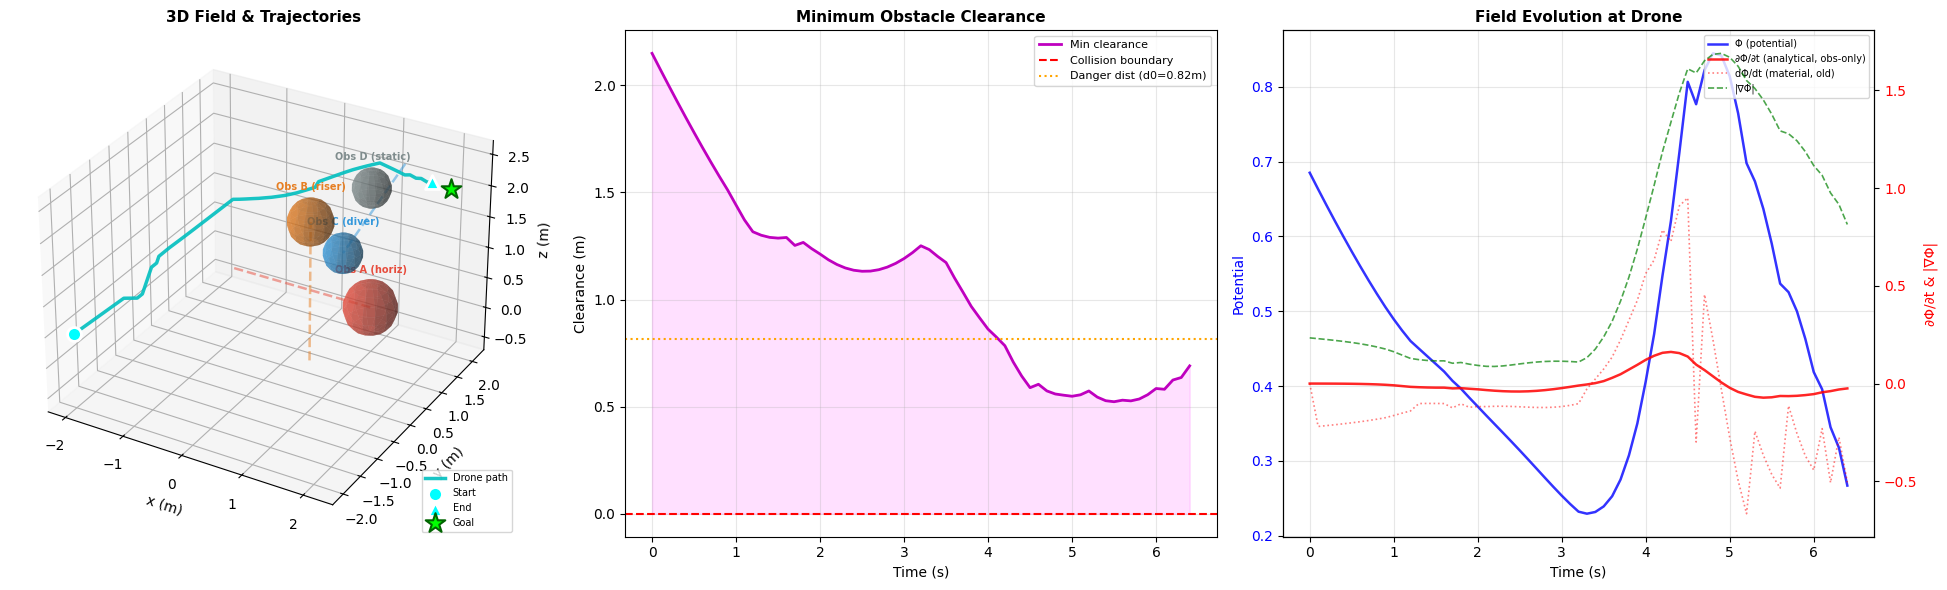

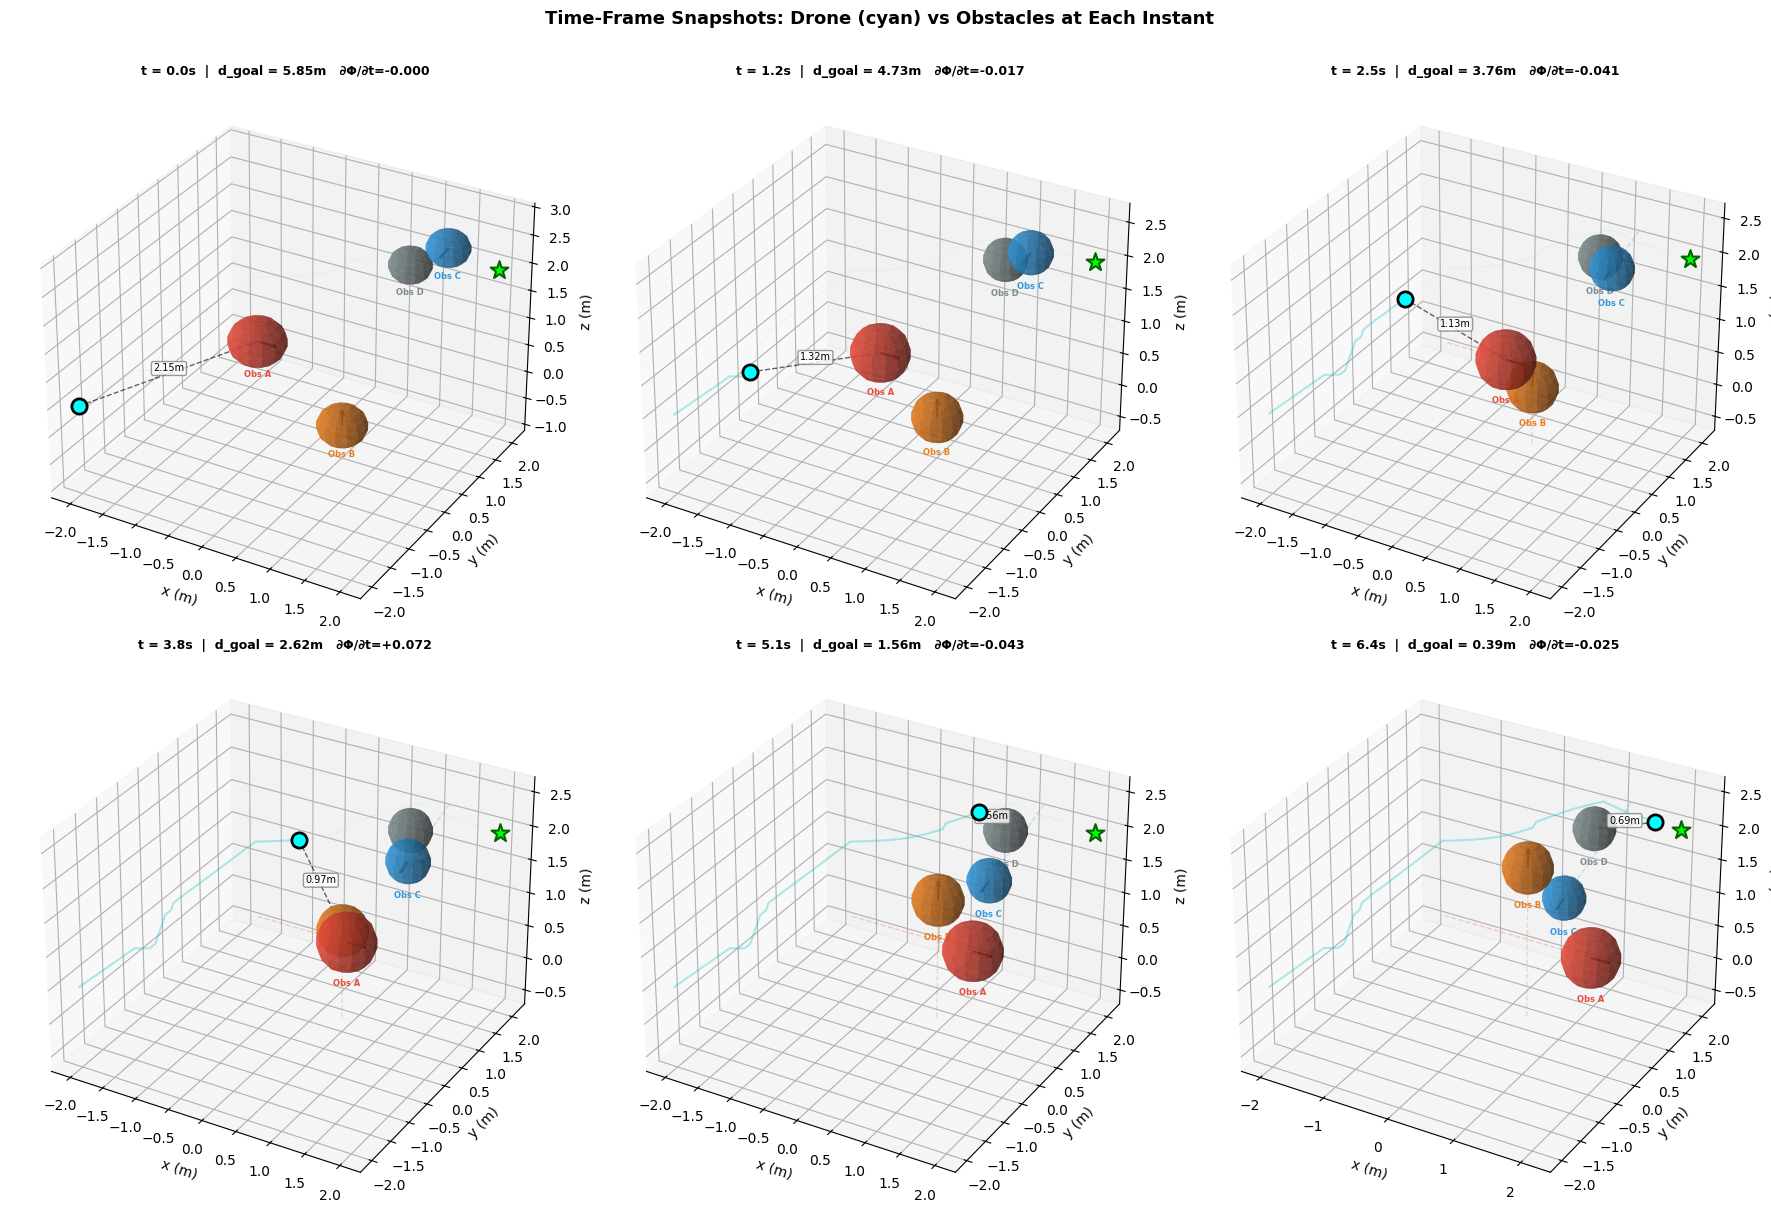

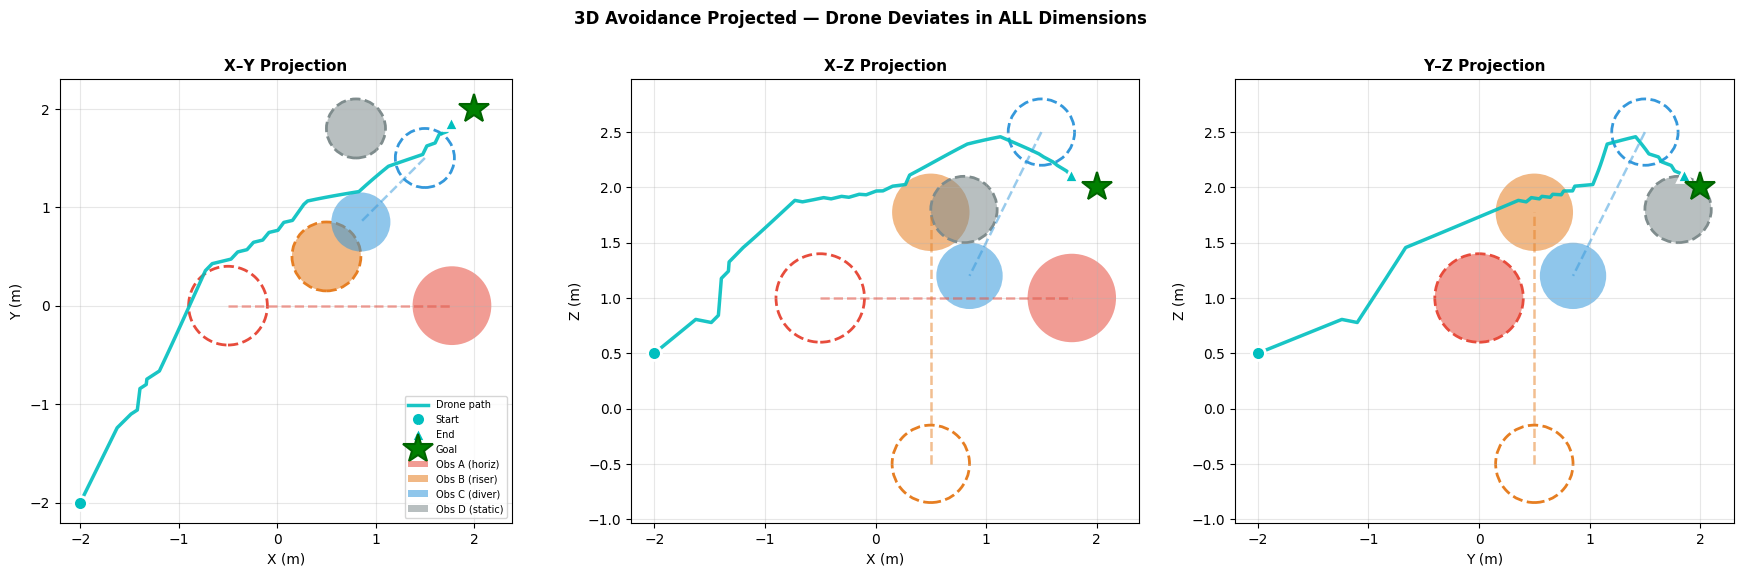


3D DYNAMIC OBSTACLE AVOIDANCE - SUMMARY
  Steps          : 65
  Sim time       : 6.5 s
  Path length    : 6.50 m  (straight-line: 5.85 m, ratio: 1.11)
  Goal reached   : YES
  Collision      : NO
  Min clearance  : 0.523 m
  ∂Φ/∂t range   : [-0.0723, 0.1618]  (analytical)
  dΦ/dt range   : [-0.6658, 0.9497]  (material, old)
  |∇Φ| range    : [0.0875, 1.6891]
  Obs A (horiz)       : moved 2.27 m,  final pos [+1.77, +0.00, +1.00]
  Obs B (riser)       : moved 2.27 m,  final pos [+0.50, +0.50, +1.77]
  Obs C (diver)       : moved 1.59 m,  final pos [+0.85, +0.85, +1.20]
  Obs D (static)      : moved 0.00 m,  final pos [+0.80, +1.80, +1.80]


In [5]:
def demo_3_dynamic_obstacles_3d():
    """
    Dynamic Multi-Obstacle Avoidance in 3D using Analytical Subharmonic Fields
    ===========================================================================
    Multiple obstacles move with different velocities at different altitudes,
    crossing the drone's planned path. The analytical subharmonic field
    (arXiv:2402.11601) adapts via update_field_analytical().

    Navigation uses gradient descent + spherical sampling (3D extension of
    Section IV circular sampling).

    Temporal derivative ∂Φ/∂t is computed analytically (closed-form via
    chain rule through Gaussian barriers), giving a pure obstacle-motion
    signal decoupled from agent movement.

    Scenario (6x6x6 workspace):
      - Drone: (-2, -2, 0.5) -> goal (2, 2, 2)
      - Obs A: horizontal sweeper at mid-altitude z=1.0 (fast)
      - Obs B: vertical riser climbing through flight corridor
      - Obs C: diagonal diver descending across the path
      - Obs D: static guard near the goal
    """
    print("Demo 3 (3D): DYNAMIC MULTI-OBSTACLE AVOIDANCE (Analytical Subharmonic)")
    print("=" * 65)

    pf = PotentialFieldEngine2D(
        x_bounds=(-3.0, 3.0),
        y_bounds=(-3.0, 3.0),
        grid_resolution=80,
        goal_position=np.array([2.0, 2.0, 2.0]),
        max_iterations=500,
        convergence_threshold=1e-4,
    )

    obs_A_pos = np.array([-0.5, 0.0, 1.0])
    obs_A_vel = np.array([0.35, 0.0, 0.0])
    pf.add_obstacle(position=obs_A_pos.copy(), radius=0.40, velocity=obs_A_vel)

    obs_B_pos = np.array([0.5, 0.5, -0.5])
    obs_B_vel = np.array([0.0, 0.0, 0.35])
    pf.add_obstacle(position=obs_B_pos.copy(), radius=0.35, velocity=obs_B_vel)

    obs_C_pos = np.array([1.5, 1.5, 2.5])
    obs_C_vel = np.array([-0.10, -0.10, -0.20])
    pf.add_obstacle(position=obs_C_pos.copy(), radius=0.30, velocity=obs_C_vel)

    obs_D_pos = np.array([0.8, 1.8, 1.8])
    pf.add_obstacle(position=obs_D_pos.copy(), radius=0.30)

    print(f"  Obs A: pos={obs_A_pos}, vel={obs_A_vel}, r=0.40  (horiz sweeper z=1)")
    print(f"  Obs B: pos={obs_B_pos}, vel={obs_B_vel}, r=0.35  (vertical riser)")
    print(f"  Obs C: pos={obs_C_pos}, vel={obs_C_vel}, r=0.30  (diagonal diver)")
    print(f"  Obs D: pos={obs_D_pos}, vel=[0,0,0],      r=0.30  (static guard)")

    # subharmonic parameters (Eq. 23  arXiv:2402.11601)
    a_att = 0.02
    a_rep = 1.0
    k_rep = 1.5     # danger distance = 1/sqrt(1.5) approx 0.82 m

    # flip into analytical mode directly (grid is 2D-only, irrelevant for 3D nav)
    pf.subharmonic_mode = True
    pf.a_att = a_att
    pf.a_rep = a_rep
    pf.k_rep = k_rep
    pf.danger_distance = np.sqrt(1.0 / k_rep)
    pf.phi_prev = pf.phi.copy()
    pf.dt = 0.1

    # drone
    agent_pos  = np.array([-2.0, -2.0, 0.5])
    alpha      = 0.8   # proportional gain for step size scaling for GD
    dt         = 0.10
    max_steps  = 500
    goal_thr   = 0.35
    coll_thr   = 0.05
    max_speed  = 1.0

    sample_radius = 0.3
    n_samples     = 32

    print(f"\n  Drone start : {agent_pos}")
    print(f"  Goal        : {pf.goal_position}")
    print(f"  a_att={a_att}, a_rep={a_rep}, k_rep={k_rep}")
    print(f"  Danger distance d0 = {pf.danger_distance:.2f} m")

    # storage
    traj       = [agent_pos.copy()]
    obs_trajs  = [[obs.position.copy() for obs in pf.obstacles]]
    potentials = []
    grad_mags  = []
    dphi_dts   = []          # analytical ∂Φ/∂t (obstacle-motion signal)
    dphi_dt_material = []    # material dΦ/dt (for comparison)

    reached  = False
    collided = False

    # ── 3D spherical sampling (Fibonacci sphere, Section IV extension) ──
    def spherical_sample(pf, raw_next, current_pos, sample_radius, n_samples):
        golden = (1 + np.sqrt(5)) / 2
        candidates = []
        for i in range(n_samples):
            theta = np.arccos(1 - 2 * (i + 0.5) / n_samples)
            phi_angle = 2 * np.pi * i / golden
            candidate = raw_next + sample_radius * np.array([
                np.sin(theta) * np.cos(phi_angle),
                np.sin(theta) * np.sin(phi_angle),
                np.cos(theta)])

            safe = True
            for obs in pf.obstacles:
                if np.linalg.norm(candidate - obs.position) < pf.danger_distance:
                    safe = False
                    break
            if safe:
                candidates.append(candidate)

        if len(candidates) == 0:
            return raw_next

        best_candidate = candidates[0]
        best_distance = float('inf')
        for candidate in candidates:
            grad = pf.compute_gradient(candidate)
            grad_mag = np.linalg.norm(grad)
            if grad_mag > 1e-8:
                next_next = candidate - (grad / grad_mag) * sample_radius * 0.5
            else:
                next_next = candidate
            dist_to_goal = np.linalg.norm(next_next - pf.goal_position)
            if dist_to_goal < best_distance:
                best_distance = dist_to_goal
                best_candidate = candidate
        return best_candidate

    # simulation loop
    for step in range(max_steps):
        pot  = pf.compute_potential(agent_pos)
        grad = pf.compute_gradient(agent_pos)
        grad_mag = np.linalg.norm(grad)

        potentials.append(pot)
        grad_mags.append(grad_mag)

        # temporal derivatives
        # analytical ∂Φ/∂t = Σ_i 2·k·a_rep·exp(-k·‖x-x_oi‖²)·(x-x_oi)·v_oi
        dphi_dts.append(pf.compute_dphi_dt(agent_pos))

        # material dΦ/dt for comparison (includes agent motion + field change)
        if step > 0:
            dphi_dt_material.append((pot - potentials[-2]) / dt)
        else:
            dphi_dt_material.append(0.0)

        if grad_mag > 1e-8:
            step_size = min(alpha * grad_mag, max_speed) * dt
            direction = -grad / grad_mag
            raw_next = agent_pos + direction * step_size
        else:
            raw_next = agent_pos.copy()

        refined_next = spherical_sample(
            pf, raw_next, agent_pos, sample_radius, n_samples
        )

        move_vec = refined_next - agent_pos
        move_dist = np.linalg.norm(move_vec)
        max_move = max_speed * dt
        if move_dist > max_move:
            move_vec = move_vec / move_dist * max_move
        agent_pos = agent_pos + move_vec

        traj.append(agent_pos.copy())

        # update obstacles (manual since we're bypassing grid)
        for obstacle in pf.obstacles:
            obstacle.update_position(dt)
        pf.current_time += dt

        # bounce off [-3, 3]^3
        for obs in pf.obstacles:
            if obs.velocity is not None:
                for dim in range(3):
                    lo = -3.0 + obs.radius
                    hi =  3.0 - obs.radius
                    if obs.position[dim] <= lo or obs.position[dim] >= hi:
                        obs.velocity[dim] *= -1
                        obs.position[dim] = np.clip(obs.position[dim], lo, hi)

        obs_trajs.append([obs.position.copy() for obs in pf.obstacles])

        d_goal = np.linalg.norm(agent_pos - pf.goal_position)
        if d_goal < goal_thr:
            print(f"\n  >> Goal reached at step {step}  (d={d_goal:.3f} m, t={step*dt:.1f} s)")
            reached = True
            break

        for obs in pf.obstacles:
            if np.linalg.norm(agent_pos - obs.position) < obs.radius + coll_thr:
                print(f"\n  >> Collision at step {step}!")
                collided = True
                break
        if collided:
            break

        if step % 50 == 0:
            print(f"  t={step*dt:5.1f}s  drone=[{agent_pos[0]:+.2f},{agent_pos[1]:+.2f},{agent_pos[2]:+.2f}]  "
                  f"d_goal={d_goal:.2f}  |grad|={grad_mags[-1]:.4f}  "
                  f"∂Φ/∂t={dphi_dts[-1]:+.4f}")

    traj      = np.array(traj)
    obs_trajs = np.array(obs_trajs)   # shape (T+1, n_obs, 3)
    n_obs     = len(pf.obstacles)
    radii     = [obs.radius for obs in pf.obstacles]

    # FROM HERE FOR THE REST OF THE CODE, WE FOCUS ON VISUALIZATION AND ANALYSIS OF RESULTS
    # THIS IS DONE WITH AI GENERATED CODE BECAUSE I CAN'T MAKE THE PLOTS AS PRETTY MANNUALLY
    # -------------------------------------------------------------------

    # Min clearance over time (computed once, used in multiple panels)
    t_arr = np.arange(len(potentials)) * dt
    min_dists = []
    for si in range(len(traj) - 1):
        dists = [np.linalg.norm(traj[si] - obs_trajs[si, oi]) - radii[oi]
                 for oi in range(n_obs)]
        min_dists.append(min(dists))

    colors_obs = ['#e74c3c', '#e67e22', '#3498db', '#7f8c8d']
    labels_obs = ['Obs A (horiz)', 'Obs B (riser)', 'Obs C (diver)', 'Obs D (static)']

    # helper: draw wireframe sphere on a 3D axis
    def draw_sphere(ax, center, radius, color, alpha=0.25):
        u = np.linspace(0, 2 * np.pi, 15)
        v = np.linspace(0, np.pi, 10)
        xs = center[0] + radius * np.outer(np.cos(u), np.sin(v))
        ys = center[1] + radius * np.outer(np.sin(u), np.sin(v))
        zs = center[2] + radius * np.outer(np.ones_like(u), np.cos(v))
        ax.plot_surface(xs, ys, zs, color=color, alpha=alpha)

    # ====================================================================
    #  FIGURE 1: Overview  (3D trajectories, clearance, time-series)
    # ====================================================================
    fig1 = plt.figure(figsize=(20, 6))

    # --- Panel 1: 3D trajectory + obstacles ----------------------------
    ax = fig1.add_subplot(131, projection='3d')

    ax.plot(traj[:, 0], traj[:, 1], traj[:, 2], 'c-', lw=2.5, alpha=0.9, label='Drone path')
    ax.scatter(*traj[0],  color='cyan', s=100, marker='o', edgecolors='white',
               linewidths=2, label='Start', zorder=10)
    ax.scatter(*traj[-1], color='cyan', s=100, marker='^', edgecolors='white',
               linewidths=2, label='End', zorder=10)
    ax.scatter(*pf.goal_position, color='lime', s=220, marker='*',
               edgecolors='darkgreen', linewidths=1.5, label='Goal', zorder=10)

    for i in range(n_obs):
        ax.plot(obs_trajs[:, i, 0], obs_trajs[:, i, 1], obs_trajs[:, i, 2],
                '--', color=colors_obs[i], lw=1.8, alpha=0.5)
        draw_sphere(ax, obs_trajs[-1, i], radii[i], colors_obs[i], alpha=0.55)
        ax.text(obs_trajs[-1, i, 0], obs_trajs[-1, i, 1],
                obs_trajs[-1, i, 2] + radii[i] + 0.15,
                labels_obs[i], fontsize=7, ha='center',
                color=colors_obs[i], fontweight='bold')

    ax.set_title('3D Field & Trajectories', fontweight='bold', fontsize=11)
    ax.set_xlabel('x (m)'); ax.set_ylabel('y (m)'); ax.set_zlabel('z (m)')
    ax.legend(fontsize=7, loc='lower right')

    # --- Panel 2: Min obstacle clearance over time ---------------------
    ax = fig1.add_subplot(132)
    ax.plot(t_arr, min_dists, 'm-', lw=2, label='Min clearance')
    ax.axhline(y=0, color='r', ls='--', lw=1.5, label='Collision boundary')
    ax.axhline(y=pf.danger_distance, color='orange', ls=':', lw=1.5,
               label=f'Danger dist (d0={pf.danger_distance:.2f}m)')
    ax.fill_between(t_arr, 0, min_dists, alpha=0.12, color='magenta')
    ax.set_xlabel('Time (s)'); ax.set_ylabel('Clearance (m)')
    ax.set_title('Minimum Obstacle Clearance', fontweight='bold', fontsize=11)
    ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

    # --- Panel 3: Potential + both temporal derivatives -----------------
    ax = fig1.add_subplot(133)
    ax.plot(t_arr, potentials, 'b-', lw=1.8, label='Φ (potential)', alpha=0.8)
    ax2 = ax.twinx()
    ax2.plot(t_arr, dphi_dts, 'r-', lw=1.8,
             label='∂Φ/∂t (analytical, obs-only)', alpha=0.85)
    ax2.plot(t_arr, dphi_dt_material, 'r:', lw=1.2,
             label='dΦ/dt (material, old)', alpha=0.5)
    ax2.plot(t_arr, grad_mags, 'g--', lw=1.2, label='|∇Φ|', alpha=0.7)
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('Potential', color='b')
    ax2.set_ylabel('∂Φ/∂t & |∇Φ|', color='r')
    ax.tick_params(axis='y', labelcolor='b')
    ax2.tick_params(axis='y', labelcolor='r')
    h1, l1 = ax.get_legend_handles_labels()
    h2, l2 = ax2.get_legend_handles_labels()
    ax.legend(h1+h2, l1+l2, loc='upper right', fontsize=7)
    ax.set_title('Field Evolution at Drone', fontweight='bold', fontsize=11)
    ax.grid(True, alpha=0.3)

    fig1.tight_layout()
    fig1.savefig('visualizations/demo3_3d_overview.png', dpi=150, bbox_inches='tight')
    plt.show()

    # ====================================================================
    #  FIGURE 2: Individual time-frame snapshots (3D)
    #  Each subplot shows ONE instant: drone position, obstacle positions,
    #  danger zones, and clearance lines — no stacking from other times.
    # ====================================================================
    n_frames = 6
    n_snap = min(len(traj) - 1, max_steps)
    snap_indices = np.linspace(0, n_snap - 1, n_frames, dtype=int)

    fig2, axes2 = plt.subplots(2, 3, figsize=(18, 12),
                               subplot_kw={'projection': '3d'})
    axes_flat = axes2.flatten()

    for idx, si in enumerate(snap_indices):
        ax = axes_flat[idx]
        t_val = si * dt

        # Light background: drone path so far (faded)
        ax.plot(traj[:si+1, 0], traj[:si+1, 1], traj[:si+1, 2],
                'c-', lw=1.5, alpha=0.3,
                label='Path so far' if idx == 0 else '')
        if si < len(traj) - 1:
            ax.plot(traj[si:, 0], traj[si:, 1], traj[si:, 2],
                    'c:', lw=0.8, alpha=0.15)

        for i in range(n_obs):
            ax.plot(obs_trajs[:si+1, i, 0], obs_trajs[:si+1, i, 1],
                    obs_trajs[:si+1, i, 2],
                    '--', color=colors_obs[i], lw=1, alpha=0.25)

        # --- THIS INSTANT: obstacles with solid spheres ----------------
        for i in range(n_obs):
            ox, oy, oz = obs_trajs[si, i]
            r = radii[i]

            draw_sphere(ax, obs_trajs[si, i], r, colors_obs[i], alpha=0.7)

            obs = pf.obstacles[i]
            if obs.velocity is not None and np.linalg.norm(obs.velocity) > 0:
                v = obs.velocity
                ax.quiver(ox, oy, oz, v[0]*0.8, v[1]*0.8, v[2]*0.8,
                          color='black', arrow_length_ratio=0.3, linewidth=1.5)

            ax.text(ox, oy, oz - r - 0.25,
                    labels_obs[i].split('(')[0].strip(),
                    fontsize=6, ha='center', color=colors_obs[i], fontweight='bold')

        # --- THIS INSTANT: drone position ------------------------------
        ax.scatter(traj[si, 0], traj[si, 1], traj[si, 2],
                   color='cyan', s=120, marker='o',
                   edgecolors='black', linewidths=2, zorder=10)

        # Clearance line from drone to nearest obstacle at this instant
        dists_now = [np.linalg.norm(traj[si] - obs_trajs[si, oi])
                     for oi in range(n_obs)]
        nearest_idx = np.argmin(dists_now)
        nearest_dist = dists_now[nearest_idx] - radii[nearest_idx]
        ax.plot([traj[si, 0], obs_trajs[si, nearest_idx, 0]],
                [traj[si, 1], obs_trajs[si, nearest_idx, 1]],
                [traj[si, 2], obs_trajs[si, nearest_idx, 2]],
                'k--', lw=1, alpha=0.6)
        mid = (traj[si] + obs_trajs[si, nearest_idx]) / 2
        ax.text(mid[0], mid[1], mid[2], f'{nearest_dist:.2f}m',
                fontsize=7, ha='center', va='bottom',
                bbox=dict(boxstyle='round,pad=0.2', fc='white', ec='gray', alpha=0.8))

        ax.scatter(*pf.goal_position, color='lime', s=180, marker='*',
                   edgecolors='darkgreen', linewidths=1.5, zorder=5)

        d_goal_now = np.linalg.norm(traj[si] - pf.goal_position)

        # ∂Φ/∂t in title (can't use axes fraction annotation in 3D easily)
        dphi_str = ''
        if si < len(dphi_dts):
            dphi_val = dphi_dts[si]
            dphi_str = f'   ∂Φ/∂t={dphi_val:+.3f}'
        ax.set_title(f't = {t_val:.1f}s  |  d_goal = {d_goal_now:.2f}m{dphi_str}',
                     fontweight='bold', fontsize=9)
        ax.set_xlabel('x (m)'); ax.set_ylabel('y (m)'); ax.set_zlabel('z (m)')

    fig2.suptitle('Time-Frame Snapshots: Drone (cyan) vs Obstacles at Each Instant',
                  fontsize=13, fontweight='bold', y=1.01)
    fig2.tight_layout()
    fig2.savefig('visualizations/demo3_3d_snapshots.png', dpi=150, bbox_inches='tight')
    plt.show()

    # ====================================================================
    #  FIGURE 3: XY / XZ / YZ projections (see 3D avoidance clearly)
    # ====================================================================
    fig3, axes3 = plt.subplots(1, 3, figsize=(18, 5.5))
    proj_labels = [('X', 'Y', 0, 1), ('X', 'Z', 0, 2), ('Y', 'Z', 1, 2)]

    for idx, (xlabel, ylabel, d0, d1) in enumerate(proj_labels):
        ax = axes3[idx]
        ax.plot(traj[:, d0], traj[:, d1], 'c-', lw=2.5, alpha=0.9, label='Drone path')
        ax.plot(traj[0, d0], traj[0, d1], 'co', ms=10, mec='w', mew=2, label='Start')
        ax.plot(traj[-1, d0], traj[-1, d1], 'c^', ms=10, mec='w', mew=2, label='End')
        ax.plot(pf.goal_position[d0], pf.goal_position[d1],
                'g*', ms=22, mec='darkgreen', mew=1.5, label='Goal')

        for i in range(n_obs):
            ax.plot(obs_trajs[:, i, d0], obs_trajs[:, i, d1],
                    '--', color=colors_obs[i], lw=1.8, alpha=0.5)
            ax.add_patch(plt.Circle((obs_trajs[0, i, d0], obs_trajs[0, i, d1]),
                                     radii[i], fc='none', ec=colors_obs[i], ls='--', lw=2))
            ax.add_patch(plt.Circle((obs_trajs[-1, i, d0], obs_trajs[-1, i, d1]),
                                     radii[i], fc=colors_obs[i], alpha=0.55,
                                     label=labels_obs[i] if idx == 0 else ''))

        ax.set_xlabel(f'{xlabel} (m)'); ax.set_ylabel(f'{ylabel} (m)')
        ax.set_title(f'{xlabel}–{ylabel} Projection', fontweight='bold', fontsize=11)
        ax.set_aspect('equal'); ax.grid(True, alpha=0.3)
        if idx == 0:
            ax.legend(fontsize=7, loc='lower right')

    fig3.suptitle('3D Avoidance Projected — Drone Deviates in ALL Dimensions',
                  fontweight='bold', fontsize=12, y=1.02)
    fig3.tight_layout()
    fig3.savefig('visualizations/demo3_3d_projections.png', dpi=150, bbox_inches='tight')
    plt.show()

    # ====================================================================
    #  SUMMARY
    # ====================================================================
    total_dist = np.sum(np.linalg.norm(np.diff(traj, axis=0), axis=1))
    straight   = np.linalg.norm(pf.goal_position - traj[0])
    print("\n" + "=" * 65)
    print("3D DYNAMIC OBSTACLE AVOIDANCE - SUMMARY")
    print("=" * 65)
    print(f"  Steps          : {len(traj) - 1}")
    print(f"  Sim time       : {(len(traj)-1)*dt:.1f} s")
    print(f"  Path length    : {total_dist:.2f} m  (straight-line: {straight:.2f} m, ratio: {total_dist/straight:.2f})")
    print(f"  Goal reached   : {'YES' if reached else 'NO'}")
    print(f"  Collision      : {'YES' if collided else 'NO'}")
    print(f"  Min clearance  : {min(min_dists):.3f} m")
    print(f"  ∂Φ/∂t range   : [{min(dphi_dts):.4f}, {max(dphi_dts):.4f}]  (analytical)")
    print(f"  dΦ/dt range   : [{min(dphi_dt_material):.4f}, {max(dphi_dt_material):.4f}]  (material, old)")
    print(f"  |∇Φ| range    : [{min(grad_mags):.4f}, {max(grad_mags):.4f}]")

    for i, obs in enumerate(pf.obstacles):
        d_travel = np.sum(np.linalg.norm(np.diff(obs_trajs[:, i], axis=0), axis=1))
        print(f"  {labels_obs[i]:20s}: moved {d_travel:.2f} m,  final pos [{obs.position[0]:+.2f}, {obs.position[1]:+.2f}, {obs.position[2]:+.2f}]")

demo_3_dynamic_obstacles_3d()

Demo 3 (3D + CHASER): DYNAMIC MULTI-OBSTACLE AVOIDANCE
  Obs A: pos=[-0.5  0.   1. ], vel=[0.35 0.   0.  ], r=0.40  (horiz sweeper z=1)
  Obs B: pos=[ 0.5  0.5 -0.5], vel=[0.   0.   0.35], r=0.35  (vertical riser)
  Obs C: pos=[0.8 1.8 1.8], vel=[0,0,0],      r=0.30  (static guard)
  Obs E: pos=[0.  0.  1.2], speed=0.45,    r=0.35  (CHASER)

  Drone start : [-2.  -2.   0.5]
  Goal        : [2. 2. 2.]
  a_att=0.02, a_rep=1.0, k_rep=1.5
  Danger distance d0 = 0.82 m
  t=  0.0s  drone=[-1.96,-1.92,+0.53]  d_goal=5.76  chaser=2.91  ∂Φ/∂t=-0.0001
  t=  5.0s  drone=[+0.38,+0.98,+2.24]  d_goal=1.93  chaser=1.30  ∂Φ/∂t=+0.3077

  >> Goal reached at step 68  (d=0.335 m, t=6.8 s)


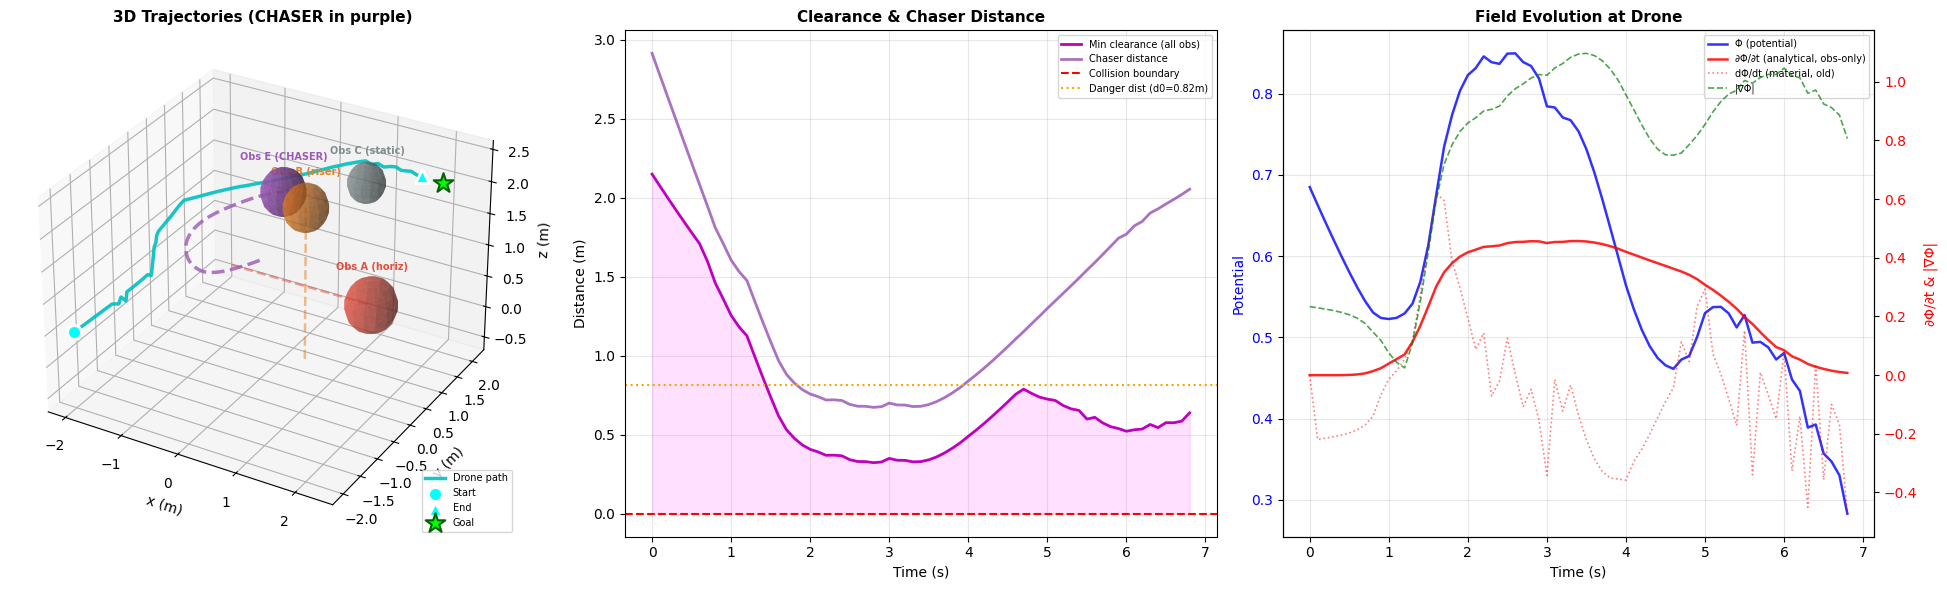

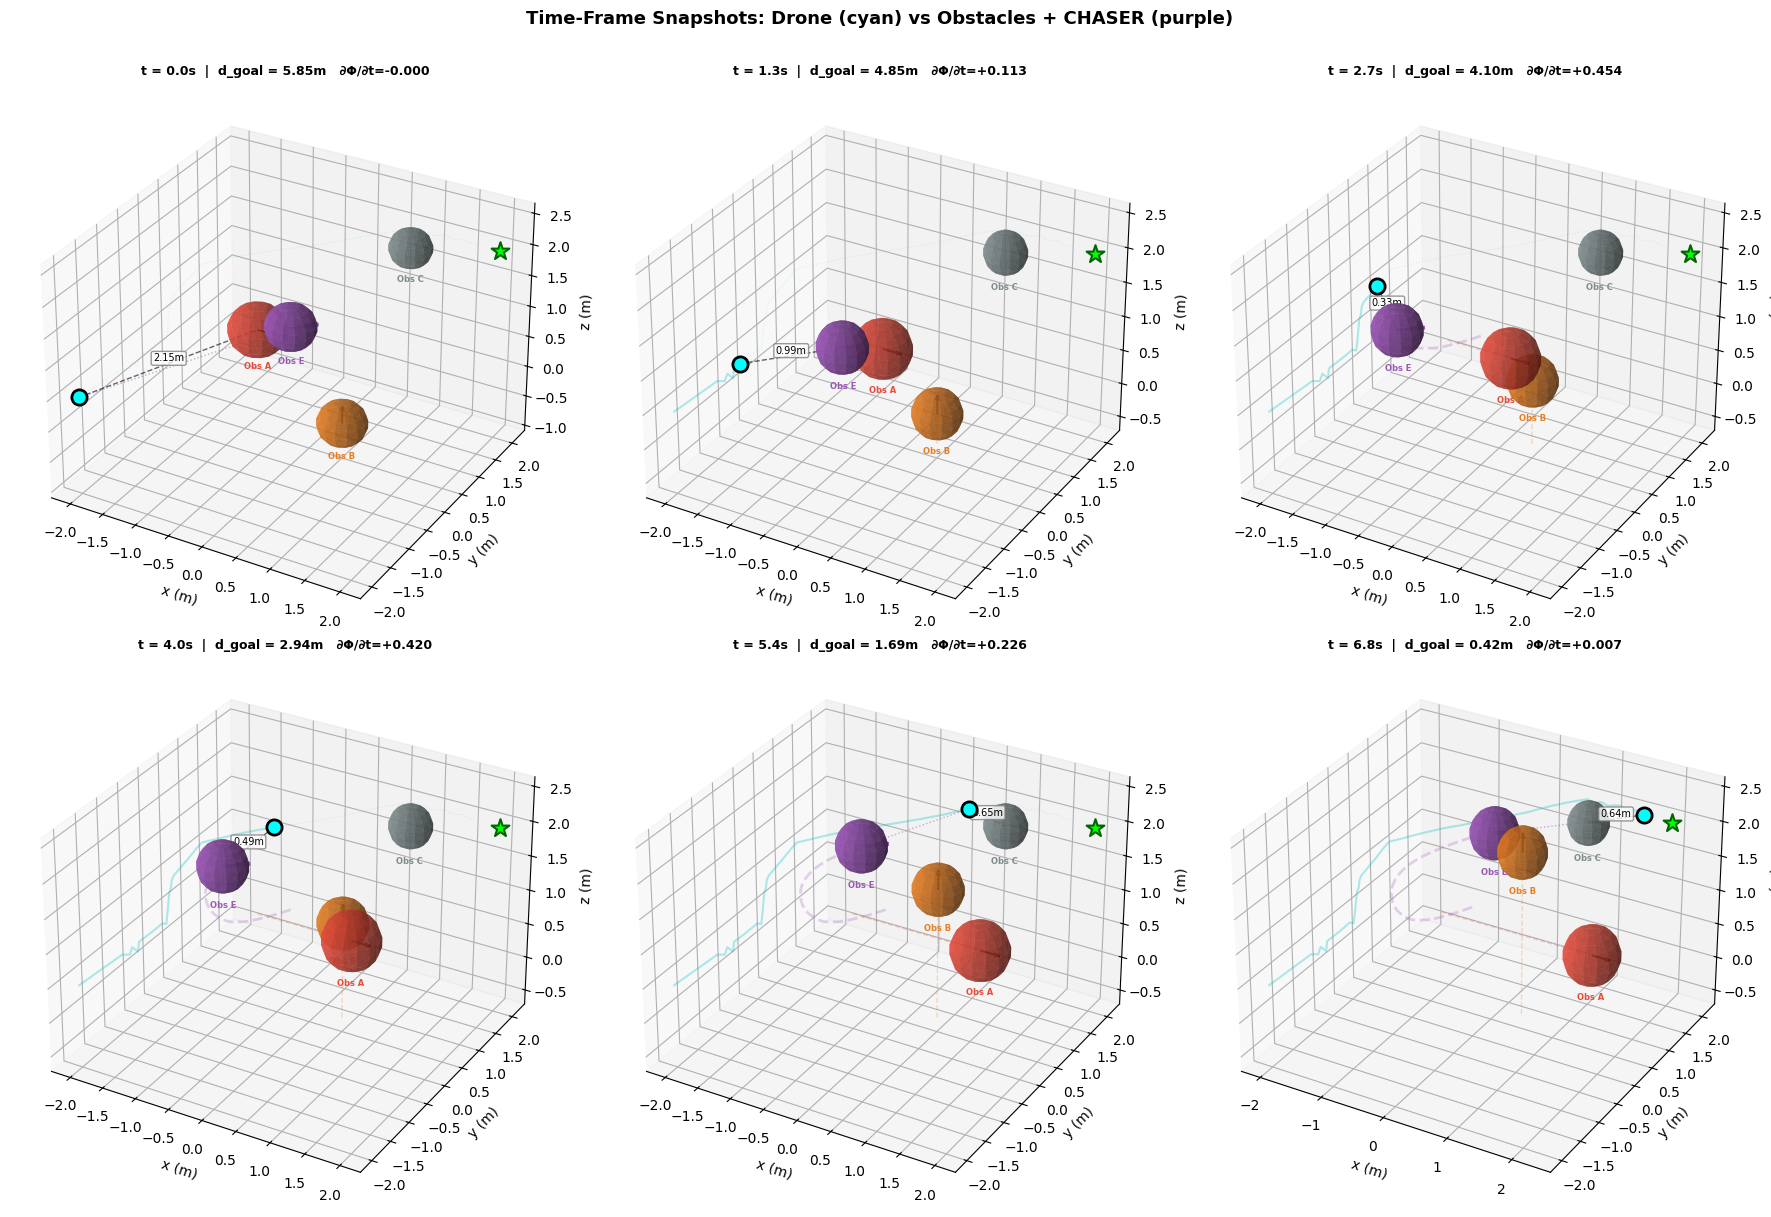

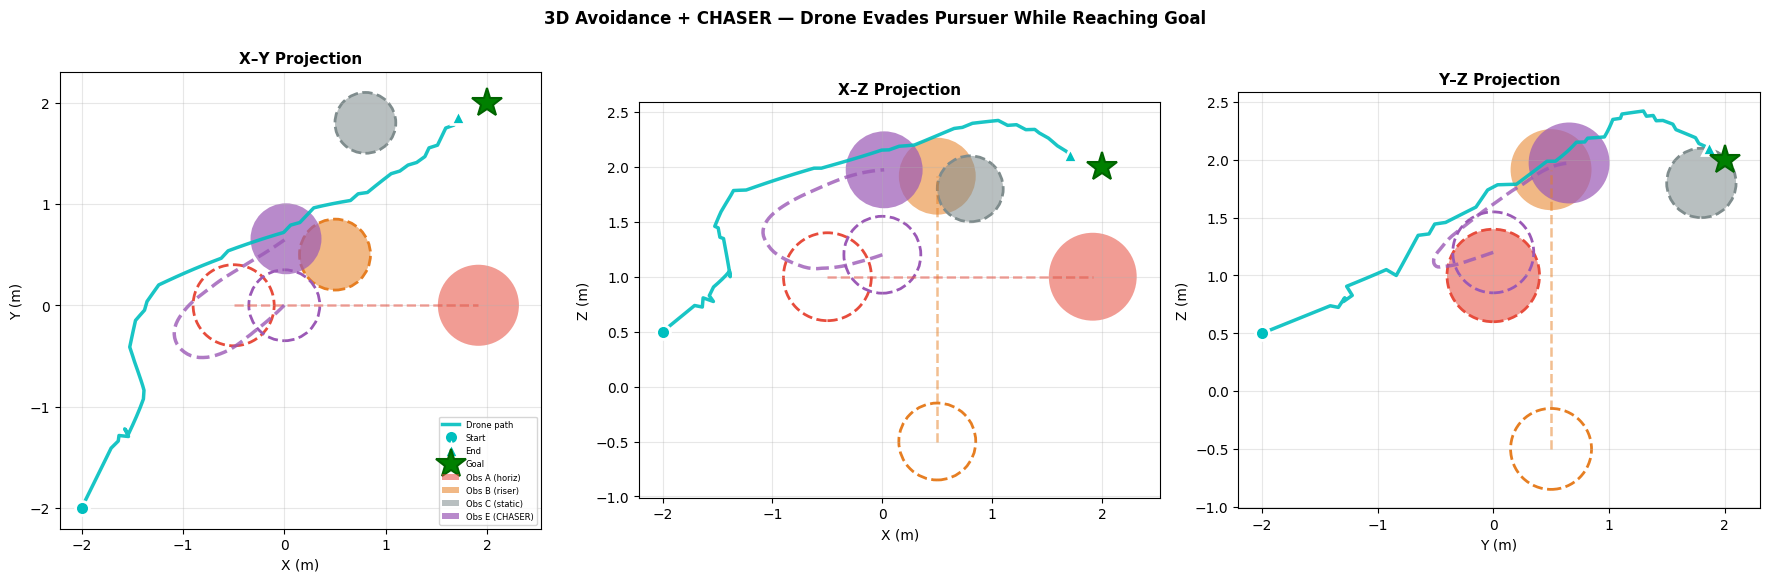


3D DYNAMIC OBSTACLE AVOIDANCE + CHASER - SUMMARY
  Steps          : 69
  Sim time       : 6.9 s
  Path length    : 6.90 m  (straight-line: 5.85 m, ratio: 1.18)
  Goal reached   : YES
  Collision      : NO
  Min clearance  : 0.323 m
  Min chaser dist: 0.673 m  (surface: 0.323 m)
  ∂Φ/∂t range   : [-0.0002, 0.4572]  (analytical)
  dΦ/dt range   : [-0.4725, 0.6186]  (material, old)
  |∇Φ| range    : [0.0247, 1.0969]
  Obs A (horiz)       : moved 2.41 m,  final pos [+1.91, +0.00, +1.00]
  Obs B (riser)       : moved 2.41 m,  final pos [+0.50, +0.50, +1.91]
  Obs C (static)      : moved 0.00 m,  final pos [+0.80, +1.80, +1.80]
  Obs E (CHASER)      : moved 3.10 m,  final pos [+0.02, +0.66, +1.97]


In [6]:
def demo_3_dynamic_obstacles_3d_chaser():
    """
    Dynamic Multi-Obstacle Avoidance in 3D with CHASER Obstacle
    =============================================================
    Same as demo_3_dynamic_obstacles_3d but with an added obstacle that
    chases the drone. The chaser starts ahead on the direct
    path to the goal and updates its velocity each timestep to point
    toward the drone's current position.

    This forces the drone to genuinely evade rather than smoothly
    navigate around predictable trajectories.

    Scenario (6x6x6 workspace):
      - Drone: (-2, -2, 0.5) -> goal (2, 2, 2)
      - Obs A: horizontal sweeper at mid-altitude z=1.0 (fast)
      - Obs B: vertical riser climbing through flight corridor
      - Obs C: static guard near the goal
      - Obs E: CHASER — starts ahead on the path, chases the drone
    """
    print("Demo 3 (3D + CHASER): DYNAMIC MULTI-OBSTACLE AVOIDANCE")
    print("=" * 65)

    pf = PotentialFieldEngine2D(
        x_bounds=(-3.0, 3.0),
        y_bounds=(-3.0, 3.0),
        grid_resolution=80,
        goal_position=np.array([2.0, 2.0, 2.0]),
        max_iterations=500,
        convergence_threshold=1e-4,
    )

    # regular obstacles
    obs_A_pos = np.array([-0.5, 0.0, 1.0])
    obs_A_vel = np.array([0.35, 0.0, 0.0])
    pf.add_obstacle(position=obs_A_pos.copy(), radius=0.40, velocity=obs_A_vel)

    obs_B_pos = np.array([0.5, 0.5, -0.5])
    obs_B_vel = np.array([0.0, 0.0, 0.35])
    pf.add_obstacle(position=obs_B_pos.copy(), radius=0.35, velocity=obs_B_vel)

    obs_C_pos = np.array([0.8, 1.8, 1.8])
    pf.add_obstacle(position=obs_C_pos.copy(), radius=0.30)

    # CHASER obstacle - THIS IS WHAT I ADDED TO THE SIMULATION - starts ahead of the drone on the diagonal, chases it
    chaser_pos = np.array([0.0, 0.0, 1.2])   # right in the middle of the corridor
    chaser_speed = 0.45                        # slightly slower than drone max_speed
    # initial velocity aimed at drone start
    drone_start = np.array([-2.0, -2.0, 0.5])
    chase_dir = drone_start - chaser_pos
    chase_dir = chase_dir / np.linalg.norm(chase_dir)
    chaser_vel = chase_dir * chaser_speed
    pf.add_obstacle(position=chaser_pos.copy(), radius=0.35, velocity=chaser_vel)
    chaser_idx = 3   # index in pf.obstacles

    print(f"  Obs A: pos={obs_A_pos}, vel={obs_A_vel}, r=0.40  (horiz sweeper z=1)")
    print(f"  Obs B: pos={obs_B_pos}, vel={obs_B_vel}, r=0.35  (vertical riser)")
    print(f"  Obs C: pos={obs_C_pos}, vel=[0,0,0],      r=0.30  (static guard)")
    print(f"  Obs E: pos={chaser_pos}, speed={chaser_speed},    r=0.35  (CHASER)")

    # subharmonic parameters (Eq. 23  arXiv:2402.11601)
    a_att = 0.02
    a_rep = 1.0
    k_rep = 1.5     # danger distance = 1/sqrt(1.5) approx 0.82 m

    # flip into analytical mode directly (grid is 2D-only, irrelevant for 3D nav)
    pf.subharmonic_mode = True
    pf.a_att = a_att
    pf.a_rep = a_rep
    pf.k_rep = k_rep
    pf.danger_distance = np.sqrt(1.0 / k_rep)
    pf.phi_prev = pf.phi.copy()
    pf.dt = 0.1

    # drone
    agent_pos  = drone_start.copy()
    alpha      = 0.8   # proportional gain for step size scaling for GD
    dt         = 0.10
    max_steps  = 500
    goal_thr   = 0.35
    coll_thr   = 0.05
    max_speed  = 1.0

    sample_radius = 0.3
    n_samples     = 32

    print(f"\n  Drone start : {agent_pos}")
    print(f"  Goal        : {pf.goal_position}")
    print(f"  a_att={a_att}, a_rep={a_rep}, k_rep={k_rep}")
    print(f"  Danger distance d0 = {pf.danger_distance:.2f} m")

    colors_obs = ['#e74c3c', '#e67e22', '#7f8c8d', '#9b59b6']
    labels_obs = ['Obs A (horiz)', 'Obs B (riser)', 'Obs C (static)', 'Obs E (CHASER)']

    # storage
    traj       = [agent_pos.copy()]
    obs_trajs  = [[obs.position.copy() for obs in pf.obstacles]]
    potentials = []
    grad_mags  = []
    dphi_dts   = []          # analytical ∂Φ/∂t (obstacle-motion signal)
    dphi_dt_material = []    # material dΦ/dt (for comparison)
    chaser_dists = []        # distance from chaser to drone over time

    reached  = False
    collided = False

    # ── 3D spherical sampling (Fibonacci sphere, Section IV extension) ──
    def spherical_sample(pf, raw_next, current_pos, sample_radius, n_samples):
        golden = (1 + np.sqrt(5)) / 2
        candidates = []
        for i in range(n_samples):
            theta = np.arccos(1 - 2 * (i + 0.5) / n_samples)
            phi_angle = 2 * np.pi * i / golden
            candidate = raw_next + sample_radius * np.array([
                np.sin(theta) * np.cos(phi_angle),
                np.sin(theta) * np.sin(phi_angle),
                np.cos(theta)])

            safe = True
            for obs in pf.obstacles:
                if np.linalg.norm(candidate - obs.position) < pf.danger_distance:
                    safe = False
                    break
            if safe:
                candidates.append(candidate)

        if len(candidates) == 0:
            return raw_next

        best_candidate = candidates[0]
        best_distance = float('inf')
        for candidate in candidates:
            grad = pf.compute_gradient(candidate)
            grad_mag = np.linalg.norm(grad)
            if grad_mag > 1e-8:
                next_next = candidate - (grad / grad_mag) * sample_radius * 0.5
            else:
                next_next = candidate
            dist_to_goal = np.linalg.norm(next_next - pf.goal_position)
            if dist_to_goal < best_distance:
                best_distance = dist_to_goal
                best_candidate = candidate
        return best_candidate

    # simulation loop
    for step in range(max_steps):
        pot  = pf.compute_potential(agent_pos)
        grad = pf.compute_gradient(agent_pos)
        grad_mag = np.linalg.norm(grad)

        potentials.append(pot)
        grad_mags.append(grad_mag)

        # temporal derivatives
        # analytical ∂Φ/∂t = Σ_i 2·k·a_rep·exp(-k·‖x-x_oi‖²)·(x-x_oi)·v_oi
        dphi_dts.append(pf.compute_dphi_dt(agent_pos))

        # material dΦ/dt for comparison (includes agent motion + field change)
        if step > 0:
            dphi_dt_material.append((pot - potentials[-2]) / dt)
        else:
            dphi_dt_material.append(0.0)

        # chaser distance
        chaser_dists.append(np.linalg.norm(agent_pos - pf.obstacles[chaser_idx].position))

        if grad_mag > 1e-8:
            step_size = min(alpha * grad_mag, max_speed) * dt
            direction = -grad / grad_mag
            raw_next = agent_pos + direction * step_size
        else:
            raw_next = agent_pos.copy()

        refined_next = spherical_sample(
            pf, raw_next, agent_pos, sample_radius, n_samples
        )

        move_vec = refined_next - agent_pos
        move_dist = np.linalg.norm(move_vec)
        max_move = max_speed * dt
        if move_dist > max_move:
            move_vec = move_vec / move_dist * max_move
        agent_pos = agent_pos + move_vec

        traj.append(agent_pos.copy())

        # UPDATE CHASER VELOCITY to chase drone
        chaser_obs = pf.obstacles[chaser_idx]
        chase_vec = agent_pos - chaser_obs.position
        chase_dist = np.linalg.norm(chase_vec)
        if chase_dist > 1e-6:
            chaser_obs.velocity = (chase_vec / chase_dist) * chaser_speed

        # update all obstacle positions
        for obstacle in pf.obstacles:
            obstacle.update_position(dt)
        pf.current_time += dt

        # bounce regular obstacles off [-3, 3]^3 (not the chaser)
        for oi, obs in enumerate(pf.obstacles):
            if oi == chaser_idx:
                # clamp chaser to workspace but don't reverse velocity
                for dim in range(3):
                    obs.position[dim] = np.clip(obs.position[dim],
                                                -3.0 + obs.radius, 3.0 - obs.radius)
                continue
            if obs.velocity is not None:
                for dim in range(3):
                    lo = -3.0 + obs.radius
                    hi =  3.0 - obs.radius
                    if obs.position[dim] <= lo or obs.position[dim] >= hi:
                        obs.velocity[dim] *= -1
                        obs.position[dim] = np.clip(obs.position[dim], lo, hi)

        obs_trajs.append([obs.position.copy() for obs in pf.obstacles])

        d_goal = np.linalg.norm(agent_pos - pf.goal_position)
        if d_goal < goal_thr:
            print(f"\n  >> Goal reached at step {step}  (d={d_goal:.3f} m, t={step*dt:.1f} s)")
            reached = True
            break

        for oi, obs in enumerate(pf.obstacles):
            if np.linalg.norm(agent_pos - obs.position) < obs.radius + coll_thr:
                obs_name = labels_obs[oi] if oi < len(labels_obs) else f"Obs {oi}"
                print(f"\n  >> Collision with {obs_name} at step {step}!")
                collided = True
                break
        if collided:
            break

        if step % 50 == 0:
            print(f"  t={step*dt:5.1f}s  drone=[{agent_pos[0]:+.2f},{agent_pos[1]:+.2f},{agent_pos[2]:+.2f}]  "
                  f"d_goal={d_goal:.2f}  chaser={chaser_dists[-1]:.2f}  "
                  f"∂Φ/∂t={dphi_dts[-1]:+.4f}")

    traj      = np.array(traj)
    obs_trajs = np.array(obs_trajs)   # shape (T+1, n_obs, 3)
    n_obs     = len(pf.obstacles)
    radii     = [obs.radius for obs in pf.obstacles]

    # FROM HERE FOR THE REST OF THE CODE, WE FOCUS ON VISUALIZATION AND ANALYSIS OF RESULTS
    # THIS IS DONE WITH AI GENERATED CODE BECAUSE I CAN'T MAKE THE PLOTS AS PRETTY MANNUALLY
    # -------------------------------------------------------------------

    # Min clearance over time (computed once, used in multiple panels)
    t_arr = np.arange(len(potentials)) * dt
    min_dists = []
    for si in range(len(traj) - 1):
        dists = [np.linalg.norm(traj[si] - obs_trajs[si, oi]) - radii[oi]
                 for oi in range(n_obs)]
        min_dists.append(min(dists))

    # helper: draw wireframe sphere on a 3D axis
    def draw_sphere(ax, center, radius, color, alpha=0.25):
        u = np.linspace(0, 2 * np.pi, 15)
        v = np.linspace(0, np.pi, 10)
        xs = center[0] + radius * np.outer(np.cos(u), np.sin(v))
        ys = center[1] + radius * np.outer(np.sin(u), np.sin(v))
        zs = center[2] + radius * np.outer(np.ones_like(u), np.cos(v))
        ax.plot_surface(xs, ys, zs, color=color, alpha=alpha)

    # ====================================================================
    #  FIGURE 1: Overview  (3D trajectories, clearance, time-series)
    # ====================================================================
    fig1 = plt.figure(figsize=(20, 6))

    # --- Panel 1: 3D trajectory + obstacles ----------------------------
    ax = fig1.add_subplot(131, projection='3d')

    ax.plot(traj[:, 0], traj[:, 1], traj[:, 2], 'c-', lw=2.5, alpha=0.9, label='Drone path')
    ax.scatter(*traj[0],  color='cyan', s=100, marker='o', edgecolors='white',
               linewidths=2, label='Start', zorder=10)
    ax.scatter(*traj[-1], color='cyan', s=100, marker='^', edgecolors='white',
               linewidths=2, label='End', zorder=10)
    ax.scatter(*pf.goal_position, color='lime', s=220, marker='*',
               edgecolors='darkgreen', linewidths=1.5, label='Goal', zorder=10)

    for i in range(n_obs):
        ax.plot(obs_trajs[:, i, 0], obs_trajs[:, i, 1], obs_trajs[:, i, 2],
                '--', color=colors_obs[i], lw=1.8 if i != chaser_idx else 2.5,
                alpha=0.5 if i != chaser_idx else 0.8)
        draw_sphere(ax, obs_trajs[-1, i], radii[i], colors_obs[i],
                    alpha=0.55 if i != chaser_idx else 0.7)
        ax.text(obs_trajs[-1, i, 0], obs_trajs[-1, i, 1],
                obs_trajs[-1, i, 2] + radii[i] + 0.15,
                labels_obs[i], fontsize=7, ha='center',
                color=colors_obs[i], fontweight='bold')

    ax.set_title('3D Trajectories (CHASER in purple)', fontweight='bold', fontsize=11)
    ax.set_xlabel('x (m)'); ax.set_ylabel('y (m)'); ax.set_zlabel('z (m)')
    ax.legend(fontsize=7, loc='lower right')

    # --- Panel 2: Min obstacle clearance + chaser distance -------------
    ax = fig1.add_subplot(132)
    ax.plot(t_arr, min_dists, 'm-', lw=2, label='Min clearance (all obs)')
    ax.plot(t_arr, chaser_dists, color='#9b59b6', ls='-', lw=2,
            label='Chaser distance', alpha=0.85)
    ax.axhline(y=0, color='r', ls='--', lw=1.5, label='Collision boundary')
    ax.axhline(y=pf.danger_distance, color='orange', ls=':', lw=1.5,
               label=f'Danger dist (d0={pf.danger_distance:.2f}m)')
    ax.fill_between(t_arr, 0, min_dists, alpha=0.12, color='magenta')
    ax.set_xlabel('Time (s)'); ax.set_ylabel('Distance (m)')
    ax.set_title('Clearance & Chaser Distance', fontweight='bold', fontsize=11)
    ax.legend(fontsize=7); ax.grid(True, alpha=0.3)

    # --- Panel 3: Potential + both temporal derivatives -----------------
    ax = fig1.add_subplot(133)
    ax.plot(t_arr, potentials, 'b-', lw=1.8, label='Φ (potential)', alpha=0.8)
    ax2 = ax.twinx()
    ax2.plot(t_arr, dphi_dts, 'r-', lw=1.8,
             label='∂Φ/∂t (analytical, obs-only)', alpha=0.85)
    ax2.plot(t_arr, dphi_dt_material, 'r:', lw=1.2,
             label='dΦ/dt (material, old)', alpha=0.5)
    ax2.plot(t_arr, grad_mags, 'g--', lw=1.2, label='|∇Φ|', alpha=0.7)
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('Potential', color='b')
    ax2.set_ylabel('∂Φ/∂t & |∇Φ|', color='r')
    ax.tick_params(axis='y', labelcolor='b')
    ax2.tick_params(axis='y', labelcolor='r')
    h1, l1 = ax.get_legend_handles_labels()
    h2, l2 = ax2.get_legend_handles_labels()
    ax.legend(h1+h2, l1+l2, loc='upper right', fontsize=7)
    ax.set_title('Field Evolution at Drone', fontweight='bold', fontsize=11)
    ax.grid(True, alpha=0.3)

    fig1.tight_layout()
    fig1.savefig('visualizations/demo3_3d_chaser_overview.png', dpi=150, bbox_inches='tight')
    plt.show()

    # ====================================================================
    #  FIGURE 2: Individual time-frame snapshots (3D)
    # ====================================================================
    n_frames = 6
    n_snap = min(len(traj) - 1, max_steps)
    snap_indices = np.linspace(0, n_snap - 1, n_frames, dtype=int)

    fig2, axes2 = plt.subplots(2, 3, figsize=(18, 12),
                               subplot_kw={'projection': '3d'})
    axes_flat = axes2.flatten()

    for idx, si in enumerate(snap_indices):
        ax = axes_flat[idx]
        t_val = si * dt

        # Light background: drone path so far (faded)
        ax.plot(traj[:si+1, 0], traj[:si+1, 1], traj[:si+1, 2],
                'c-', lw=1.5, alpha=0.3,
                label='Path so far' if idx == 0 else '')
        if si < len(traj) - 1:
            ax.plot(traj[si:, 0], traj[si:, 1], traj[si:, 2],
                    'c:', lw=0.8, alpha=0.15)

        for i in range(n_obs):
            ax.plot(obs_trajs[:si+1, i, 0], obs_trajs[:si+1, i, 1],
                    obs_trajs[:si+1, i, 2],
                    '--', color=colors_obs[i],
                    lw=1 if i != chaser_idx else 2, alpha=0.25)

        # --- THIS INSTANT: obstacles with solid spheres ----------------
        for i in range(n_obs):
            ox, oy, oz = obs_trajs[si, i]
            r = radii[i]

            draw_sphere(ax, obs_trajs[si, i], r, colors_obs[i],
                        alpha=0.7 if i != chaser_idx else 0.85)

            obs = pf.obstacles[i]
            if obs.velocity is not None and np.linalg.norm(obs.velocity) > 0:
                v = obs.velocity
                ax.quiver(ox, oy, oz, v[0]*0.8, v[1]*0.8, v[2]*0.8,
                          color='black' if i != chaser_idx else '#9b59b6',
                          arrow_length_ratio=0.3,
                          linewidth=1.5 if i != chaser_idx else 2.5)

            ax.text(ox, oy, oz - r - 0.25,
                    labels_obs[i].split('(')[0].strip(),
                    fontsize=6, ha='center', color=colors_obs[i], fontweight='bold')

        # --- THIS INSTANT: drone position ------------------------------
        ax.scatter(traj[si, 0], traj[si, 1], traj[si, 2],
                   color='cyan', s=120, marker='o',
                   edgecolors='black', linewidths=2, zorder=10)

        # Clearance line from drone to nearest obstacle at this instant
        dists_now = [np.linalg.norm(traj[si] - obs_trajs[si, oi])
                     for oi in range(n_obs)]
        nearest_idx = np.argmin(dists_now)
        nearest_dist = dists_now[nearest_idx] - radii[nearest_idx]
        ax.plot([traj[si, 0], obs_trajs[si, nearest_idx, 0]],
                [traj[si, 1], obs_trajs[si, nearest_idx, 1]],
                [traj[si, 2], obs_trajs[si, nearest_idx, 2]],
                'k--', lw=1, alpha=0.6)
        mid = (traj[si] + obs_trajs[si, nearest_idx]) / 2
        ax.text(mid[0], mid[1], mid[2], f'{nearest_dist:.2f}m',
                fontsize=7, ha='center', va='bottom',
                bbox=dict(boxstyle='round,pad=0.2', fc='white', ec='gray', alpha=0.8))

        # also draw line to chaser if it's not the nearest
        if nearest_idx != chaser_idx:
            chaser_d = np.linalg.norm(traj[si] - obs_trajs[si, chaser_idx]) - radii[chaser_idx]
            ax.plot([traj[si, 0], obs_trajs[si, chaser_idx, 0]],
                    [traj[si, 1], obs_trajs[si, chaser_idx, 1]],
                    [traj[si, 2], obs_trajs[si, chaser_idx, 2]],
                    color='#9b59b6', ls=':', lw=1, alpha=0.5)

        ax.scatter(*pf.goal_position, color='lime', s=180, marker='*',
                   edgecolors='darkgreen', linewidths=1.5, zorder=5)

        d_goal_now = np.linalg.norm(traj[si] - pf.goal_position)

        # ∂Φ/∂t in title
        dphi_str = ''
        if si < len(dphi_dts):
            dphi_val = dphi_dts[si]
            dphi_str = f'   ∂Φ/∂t={dphi_val:+.3f}'
        ax.set_title(f't = {t_val:.1f}s  |  d_goal = {d_goal_now:.2f}m{dphi_str}',
                     fontweight='bold', fontsize=9)
        ax.set_xlabel('x (m)'); ax.set_ylabel('y (m)'); ax.set_zlabel('z (m)')

    fig2.suptitle('Time-Frame Snapshots: Drone (cyan) vs Obstacles + CHASER (purple)',
                  fontsize=13, fontweight='bold', y=1.01)
    fig2.tight_layout()
    fig2.savefig('visualizations/demo3_3d_chaser_snapshots.png', dpi=150, bbox_inches='tight')
    plt.show()

    # ====================================================================
    #  FIGURE 3: XY / XZ / YZ projections
    # ====================================================================
    fig3, axes3 = plt.subplots(1, 3, figsize=(18, 5.5))
    proj_labels = [('X', 'Y', 0, 1), ('X', 'Z', 0, 2), ('Y', 'Z', 1, 2)]

    for idx, (xlabel, ylabel, d0, d1) in enumerate(proj_labels):
        ax = axes3[idx]
        ax.plot(traj[:, d0], traj[:, d1], 'c-', lw=2.5, alpha=0.9, label='Drone path')
        ax.plot(traj[0, d0], traj[0, d1], 'co', ms=10, mec='w', mew=2, label='Start')
        ax.plot(traj[-1, d0], traj[-1, d1], 'c^', ms=10, mec='w', mew=2, label='End')
        ax.plot(pf.goal_position[d0], pf.goal_position[d1],
                'g*', ms=22, mec='darkgreen', mew=1.5, label='Goal')

        for i in range(n_obs):
            ax.plot(obs_trajs[:, i, d0], obs_trajs[:, i, d1],
                    '--', color=colors_obs[i],
                    lw=1.8 if i != chaser_idx else 2.5,
                    alpha=0.5 if i != chaser_idx else 0.8)
            ax.add_patch(plt.Circle((obs_trajs[0, i, d0], obs_trajs[0, i, d1]),
                                     radii[i], fc='none', ec=colors_obs[i], ls='--', lw=2))
            ax.add_patch(plt.Circle((obs_trajs[-1, i, d0], obs_trajs[-1, i, d1]),
                                     radii[i], fc=colors_obs[i],
                                     alpha=0.55 if i != chaser_idx else 0.7,
                                     label=labels_obs[i] if idx == 0 else ''))

        ax.set_xlabel(f'{xlabel} (m)'); ax.set_ylabel(f'{ylabel} (m)')
        ax.set_title(f'{xlabel}–{ylabel} Projection', fontweight='bold', fontsize=11)
        ax.set_aspect('equal'); ax.grid(True, alpha=0.3)
        if idx == 0:
            ax.legend(fontsize=6, loc='lower right')

    fig3.suptitle('3D Avoidance + CHASER — Drone Evades Pursuer While Reaching Goal',
                  fontweight='bold', fontsize=12, y=1.02)
    fig3.tight_layout()
    fig3.savefig('visualizations/demo3_3d_chaser_projections.png', dpi=150, bbox_inches='tight')
    plt.show()

    # ====================================================================
    #  SUMMARY
    # ====================================================================
    total_dist = np.sum(np.linalg.norm(np.diff(traj, axis=0), axis=1))
    straight   = np.linalg.norm(pf.goal_position - traj[0])
    print("\n" + "=" * 65)
    print("3D DYNAMIC OBSTACLE AVOIDANCE + CHASER - SUMMARY")
    print("=" * 65)
    print(f"  Steps          : {len(traj) - 1}")
    print(f"  Sim time       : {(len(traj)-1)*dt:.1f} s")
    print(f"  Path length    : {total_dist:.2f} m  (straight-line: {straight:.2f} m, ratio: {total_dist/straight:.2f})")
    print(f"  Goal reached   : {'YES' if reached else 'NO'}")
    print(f"  Collision      : {'YES' if collided else 'NO'}")
    print(f"  Min clearance  : {min(min_dists):.3f} m")
    print(f"  Min chaser dist: {min(chaser_dists):.3f} m  (surface: {min(chaser_dists)-radii[chaser_idx]:.3f} m)")
    print(f"  ∂Φ/∂t range   : [{min(dphi_dts):.4f}, {max(dphi_dts):.4f}]  (analytical)")
    print(f"  dΦ/dt range   : [{min(dphi_dt_material):.4f}, {max(dphi_dt_material):.4f}]  (material, old)")
    print(f"  |∇Φ| range    : [{min(grad_mags):.4f}, {max(grad_mags):.4f}]")

    for i, obs in enumerate(pf.obstacles):
        d_travel = np.sum(np.linalg.norm(np.diff(obs_trajs[:, i], axis=0), axis=1))
        print(f"  {labels_obs[i]:20s}: moved {d_travel:.2f} m,  final pos [{obs.position[0]:+.2f}, {obs.position[1]:+.2f}, {obs.position[2]:+.2f}]")

demo_3_dynamic_obstacles_3d_chaser()

**IMPORTANT: based on these results i basically managed to show that the flat region problem is indeed real lol - it matches with the findings of Rosell and Iñiguez
- now my research should show that i can solve this or find a way around this 

I am still working on implementation cause i need to have some gradient improvement - maybe i fucked up the normalization of the values after update

Update: MADE THE AGENT MOVE TOWARDS THE GOAL WITH JUST THE SIGNAL LETSGGOOOO